In [1]:
!pip install --force-reinstall --no-deps aiohttp==3.8.5
!pip install pingouin

  Using cached aiohttp-3.8.5-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.7 kB)
Using cached aiohttp-3.8.5-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.0 MB)
  Attempting uninstall: aiohttp
    Found existing installation: aiohttp 3.8.5
    Uninstalling aiohttp-3.8.5:
      Successfully uninstalled aiohttp-3.8.5

[notice] A new release of pip is available: 25.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from __future__ import print_function, division
import numpy as np
import sys
import pandas as pd
import os
import subprocess
import pdb
import matplotlib.pyplot as plt
sys.path.append('/home/jupyter/.local/lib/python3.10/site-packages')
import pingouin as pg

# Load survey data

In [3]:
#All of Us Controlled Tier Dataset v7 SDOH surveys

sdoh_survey_sql = """
    SELECT
        answer.person_id,
        answer.question_concept_id,
        answer.question,
        answer.answer_concept_id,
        answer.answer,
    FROM
        `""" + os.environ["WORKSPACE_CDR"] + """.ds_survey` answer   
    WHERE
        (
            question_concept_id IN (
                40192501, 40192431, 40192497, 40192493, 40192398, 40192423, 40192456, 
                40192489, 40192394, 40192522, 40192419, 40192452, 40192390, 40192415, 40192386, 40192411, 
                40192440, 40192506, 40192436, 40192469, 40192399, 40192498, 40192395,  40192494, 
                40192519, 40192457, 40192490, 40192420, 40192383, 40192511, 40192416, 40192449, 40192507, 
                40192412, 40192445, 40192503, 40192441, 40192499, 40192404, 40192437, 40192528, 40192470, 
                40192400, 40192466, 40192491, 40192396, 40192462, 40192425, 40192458, 40192388, 40192516, 
                40192384, 40192417, 40192475, 40192380, 40192446, 40192471, 40192504, 40192442, 40192500, 
                40192463, 40192496, 40192401, 40192492, 40192397, 40192525, 40192426, 40192451, 40192402,
                40192517, 40192480, 40192443, 40192476, 40192381, 40192414, 40192439, 40192505, 40192410
                
                            )
        )"""

sdoh_survey_df = pd.read_gbq(sdoh_survey_sql, dialect="standard", use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")


Downloading:   0%|          | 0/20218419 [00:00<?, ?rows/s]

In [4]:
sdoh_survey_df['person_id'].nunique()

259189

In [5]:
# All of Us Controlled Tier Dataset v7 basics and overall health
dataset_1_survey_sql = """
    SELECT
        answer.person_id,
        answer.survey_datetime,
        answer.survey,
        answer.question_concept_id,
        answer.question,
        answer.answer_concept_id,
        answer.answer,
        answer.survey_version_concept_id,
        answer.survey_version_name  
    FROM
        `""" + os.environ["WORKSPACE_CDR"] + """.ds_survey` answer   
    WHERE
        (
            question_concept_id IN (
                1585940, 1585952, 1585375, 1585370, 1585879, 1585886, 1585386, 1585766, 1585772, 1585778, 1585889 
            )
        )  
        """
survey_df = pd.read_gbq(
    dataset_1_survey_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")


Downloading:   0%|          | 0/6876753 [00:00<?, ?rows/s]

In [6]:
survey_df['question'].unique()

array(['Home Own: Current Home Own', 'Income: Annual Income',
       'Insurance: Health Insurance',
       'Overall Health: Medical Form Confidence',
       'Overall Health: Health Material Assistance',
       'Overall Health: Difficult Understand Info',
       'Living Situation: How Many Living Years',
       'Living Situation: Stable House Concern',
       'Living Situation: How Many People',
       'Education Level: Highest Grade', 'Employment: Employment Status'],
      dtype=object)

In [7]:
survey_df['person_id'].nunique()

633537

In [8]:
import pandas
import os

# This query represents dataset "hcau" for domain "survey" and was generated for All of Us Controlled Tier Dataset v8
dataset_97905435_survey_sql = """
    SELECT
        answer.person_id,
        answer.survey_datetime,
        answer.survey,
        answer.question_concept_id,
        answer.question,
        answer.answer_concept_id,
        answer.answer,
        answer.survey_version_concept_id,
        answer.survey_version_name  
    FROM
        `""" + os.environ["WORKSPACE_CDR"] + """.ds_survey` answer   
    WHERE
        (
            question_concept_id IN (SELECT
                DISTINCT concept_id                         
            FROM
                `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c                         
            JOIN
                (SELECT
                    CAST(cr.id as string) AS id                               
                FROM
                    `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr                               
                WHERE
                    concept_id IN (43528895)                               
                    AND domain_id = 'SURVEY') a 
                    ON (c.path like CONCAT('%', a.id, '.%'))                         
            WHERE
                domain_id = 'SURVEY'                         
                AND type = 'PPI'                         
                AND subtype = 'QUESTION')
        )"""

survey_df_2 = pandas.read_gbq(
    dataset_97905435_survey_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")


Downloading:   0%|          | 0/14914406 [00:00<?, ?rows/s]

In [9]:
survey_df_2['person_id'].nunique()

305857

In [10]:
# This snippet assumes you run setup first

# This code copies file in your Google Bucket and loads it into a dataframe

# Replace 'test.csv' with THE NAME of the file you're going to download from the bucket (don't delete the quotation marks)
name_of_file_in_bucket = 'Demographic_and_ancestry_covariates.csv'

########################################################################
##
################# DON'T CHANGE FROM HERE ###############################
##
########################################################################

# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')

# copy csv file from the bucket to the current working space
os.system(f"gsutil cp '{my_bucket}/data/{name_of_file_in_bucket}' .")

print(f'[INFO] {name_of_file_in_bucket} is successfully downloaded into your working space')
# save dataframe in a csv file in the same workspace as the notebook
my_dataframe = pd.read_csv(name_of_file_in_bucket)
my_dataframe = my_dataframe.drop(columns=["income", "education"])

Copying gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/Demographic_and_ancestry_covariates.csv...
/ [1 files][ 31.0 MiB/ 31.0 MiB]                                                
Operation completed over 1 objects/31.0 MiB.                                     


[INFO] Demographic_and_ancestry_covariates.csv is successfully downloaded into your working space


In [11]:
my_dataframe.shape

(162193, 26)

In [12]:
#Limit to people with 60% data for all domains
#os.system(f"gsutil cp '{my_bucket}/data/All_SDoH_data_domain_filtered_60.csv' .")

#filtered_data = pd.read_csv('All_SDoH_data_domain_filtered_60.csv')

#my_dataframe = my_dataframe[my_dataframe['person_id'].isin(filtered_data['person_id'])]



# Create variables

In [13]:
selected_questions = [1585940, 1585952, 1585375, 1585370, 1585879, 1585886, 1585386, 1585766, 1585772, 1585778, 1585889]

all_merged_data = my_dataframe.copy()

for question_id in selected_questions:
    # Filter the dataset to include only the current question
    filtered_data = survey_df[survey_df['question_concept_id'] == question_id]
    
    # Remove duplicates and keep the first occurrence of each person_id
    filtered_data = filtered_data.drop_duplicates(subset='person_id', keep='first')
    
    # Rename the 'answer' column to the question number
    filtered_data = filtered_data.rename(columns={'answer': str(question_id)})
    
    # Filter the columns by selecting 'person_id' and the current question number
    filtered_data = filtered_data[['person_id', str(question_id)]]
    
    # Merge the filtered data with the person_df DataFrame
    all_merged_data = pd.merge(all_merged_data, filtered_data, on='person_id', how='left')
    
all_merged_data = all_merged_data.rename(columns={
    '1585940': 'education',
    '1585952': 'employment',
    '1585375': 'income',
    '1585370': 'home_own',
    '1585879': 'years_living',
    '1585886': 'worried_living',
    '1585386' : 'insured',
    '1585766' : 'forms_self',
    '1585772' : 'help_read_forms',
    '1585778' : 'diff_med_info',
    '1585889' : 'number_living'
    
})
    



In [14]:
all_merged_data.shape

(162193, 37)

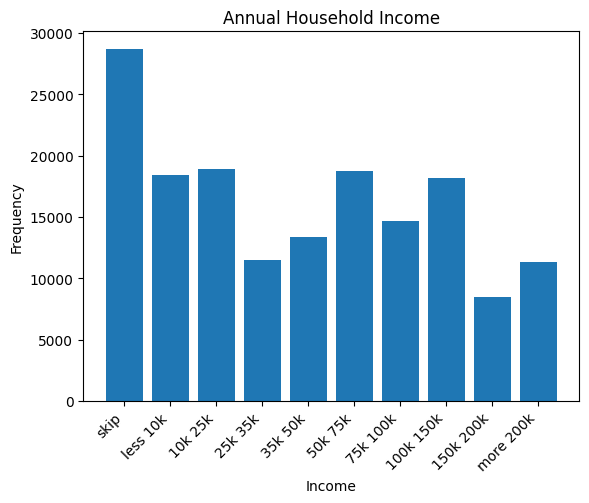

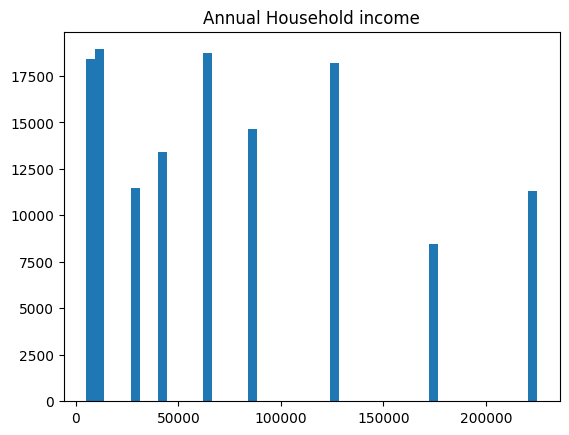

In [15]:
# Define the desired order of the income categories

all_merged_data['income'] = all_merged_data['income'].apply(lambda x: 'skip' if 'PMI:' in x else x)

income_order = ['skip', 'Annual Income: less 10k',
                'Annual Income: 10k 25k', 'Annual Income: 25k 35k', 'Annual Income: 35k 50k', 
                'Annual Income: 50k 75k', 'Annual Income: 75k 100k', 
                'Annual Income: 100k 150k', 'Annual Income: 150k 200k', 'Annual Income: more 200k']

# Convert 'income' column to categorical data with defined order
all_merged_data['income'] = pd.Categorical(all_merged_data['income'], categories=income_order, ordered=True)

income_counts = all_merged_data['income'].value_counts().sort_index()

# Strip "Annual income: " from the labels
income_counts.index = income_counts.index.str.replace("Annual Income: ", "")

# Plotting
plt.bar(income_counts.index, income_counts.values)
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.title('Annual Household Income')
plt.xticks(rotation=45, ha='right')
plt.show()

all_merged_data['income'] = all_merged_data['income'].replace({'Annual Income: less 10k': 5000,
                                                'Annual Income: 10k 25k': 12500,
                                                'Annual Income: 25k 35k': 30000,
                                                'Annual Income: 35k 50k': 42500,
                                                'Annual Income: 50k 75k': 62500,
                                                'Annual Income: 75k 100k': 87500,
                                                'Annual Income: 100k 150k': 125000,
                                                'Annual Income: 150k 200k': 175000,
                                                'Annual Income: more 200k': 225000,
                                                               'skip':np.nan})

# Plot histogram
plt.hist(all_merged_data['income'], bins='auto')
plt.title('Annual Household income')
plt.show()


In [16]:
import pandas
import os

# This query represents dataset "zip_code_socio" for domain "zip_code_socioeconomic" and was generated for All of Us Controlled Tier Dataset v8
dataset_27222903_zip_code_socioeconomic_sql = """
    SELECT
        observation.person_id,
        observation.observation_datetime,
        zip_code.zip3_as_string as zip_code,
        zip_code.fraction_assisted_income as assisted_income,
        zip_code.fraction_high_school_edu as high_school_education,
        zip_code.median_income,
        zip_code.fraction_no_health_ins as no_health_insurance,
        zip_code.fraction_poverty as poverty,
        zip_code.fraction_vacant_housing as vacant_housing,
        zip_code.deprivation_index,
        zip_code.acs as american_community_survey_year 
    FROM
        `""" + os.environ["WORKSPACE_CDR"] + """.zip3_ses_map` zip_code 
    JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.observation` observation 
            ON CAST(SUBSTR(observation.value_as_string, 0, STRPOS(observation.value_as_string, '*') - 1) AS INT64) = zip_code.zip3 
            AND observation_source_concept_id = 1585250 
            AND observation.value_as_string NOT LIKE 'Res%'"""

zip_code_socioeconomic_df = pandas.read_gbq(
    dataset_27222903_zip_code_socioeconomic_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")


Downloading:   0%|          | 0/606414 [00:00<?, ?rows/s]

In [17]:
all_merged_data['number_living'] = pd.to_numeric(all_merged_data['number_living'], errors='coerce')

all_merged_data['number_living'] = all_merged_data['number_living'] + 1

# Ensure 'income' column is numeric
all_merged_data["income"] = pd.to_numeric(all_merged_data["income"], errors='coerce')


In [18]:
# This code block is mapping various education levels to a more simplified classification.
# 'Highest Grade: Nine Through Eleven', 'Highest Grade: Five Through Eight', 'Highest Grade: One Through Four' and 'Highest Grade: Never Attended' 
# are all mapped to 'Less than high school degree or equivalent'.
# 'Highest Grade: Advanced Degree' and 'Highest Grade: College Graduate' are mapped to 'College graduate or advanced degree'.
# 'Highest Grade: Twelve Or GED' remains 'Twelve or GED'.
# 'Highest Grade: College One to Three' remains 'College One to Three'.
# 'PMI: Prefer Not To Answer' and 'PMI: Skip' are mapped to 'Skip or PNA'.
all_merged_data['education'] = all_merged_data['education'].replace({'Highest Grade: Nine Through Eleven': 1,
                                                'Highest Grade: Five Through Eight': 1,
                                                'Highest Grade: One Through Four': 1,
                                                'Highest Grade: Never Attended': 1,
                                                'Highest Grade: Advanced Degree': 5,
                                                'Highest Grade: College Graduate': 4,
                                                'Highest Grade: Twelve Or GED': 2,
                                                'Highest Grade: College One to Three': 3,
                                                'PMI: Prefer Not To Answer': np.nan,'PMI: Skip':np.nan})

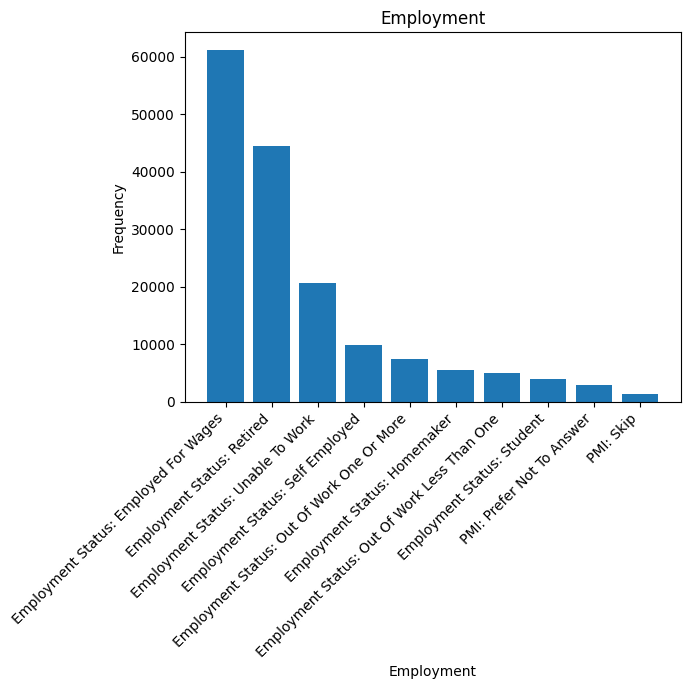

In [19]:
# Count the frequency of each employment category
employment_counts = all_merged_data['employment'].value_counts()

# Plotting
plt.bar(employment_counts.index, employment_counts.values)
plt.xlabel('Employment')
plt.ylabel('Frequency')
plt.title('Employment')
plt.xticks(rotation=45, ha='right')
plt.show()

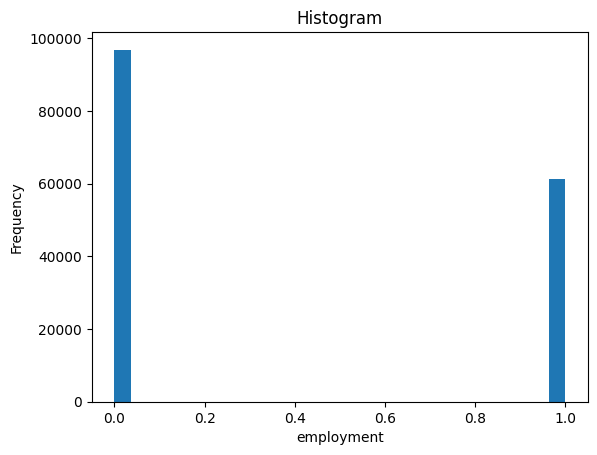

In [20]:
def recode_employment(arr):
    if 'Employed For Wages' in arr:
        return 1
    elif 'PMI: Skip' in arr or 'PMI: Prefer Not To Answer' in arr:
        return np.nan
    else:
        return 0

# Apply the function to the 'employment' column
all_merged_data['employment'] = all_merged_data['employment'].apply(recode_employment)

# Plot histogram
plt.hist(all_merged_data['employment'], bins='auto')
plt.xlabel('employment')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

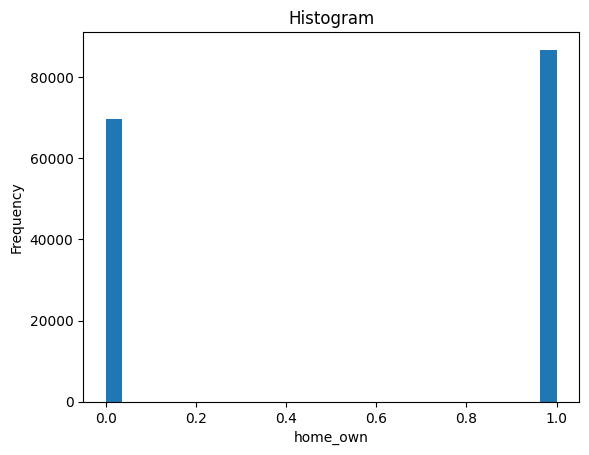

In [21]:
all_merged_data['home_own'] = all_merged_data['home_own'].replace({'Current Home Own: Own': 1,
                                                'Current Home Own: Rent': 0,
                                                'Current Home Own: Other Arrangement': 0,
                                                'PMI: Prefer Not To Answer': np.nan,
                                                'PMI: Skip': np.nan,
                                                'PMI: Dont Know': np.nan})

# Plot histogram
plt.hist(all_merged_data['home_own'], bins='auto')
plt.xlabel('home_own')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

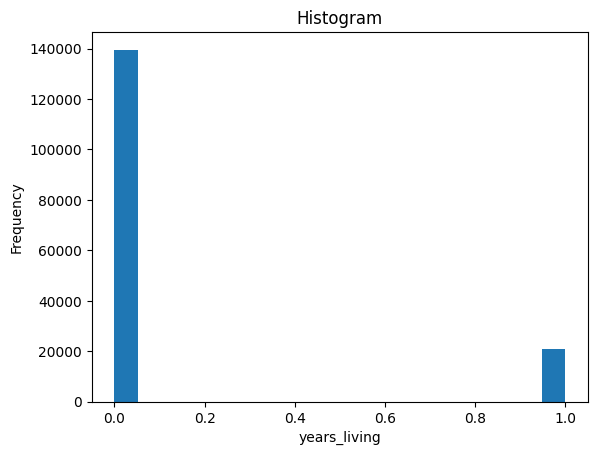

In [22]:
all_merged_data['years_living'] = all_merged_data['years_living'].replace({'How Many Living Years: more 20': 0,
                                                'How Many Living Years: 11 to 20': 0,
                                                'How Many Living Years: 6 to 10': 0,
                                                'How Many Living Years: 3 to 5': 0,
                                                'How Many Living Years: 1 to 2': 0,
                                                'How Many Living Years: less 1': 1,
                                                'PMI: Skip': np.nan})

# Plot histogram
plt.hist(all_merged_data['years_living'], bins='auto')
plt.xlabel('years_living')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

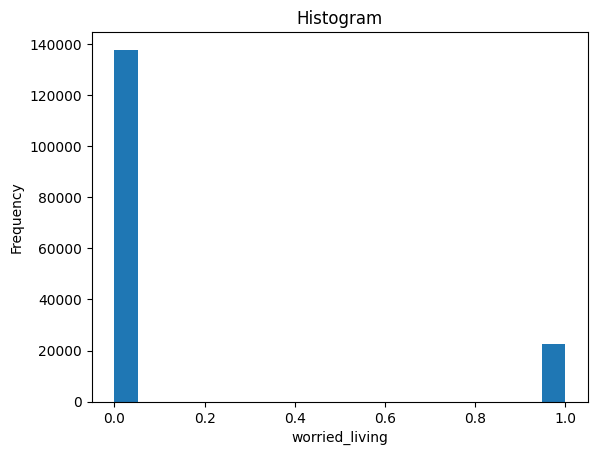

In [23]:
all_merged_data['worried_living'] = all_merged_data['worried_living'].replace({'Stable House Concern: No': 0,
                                                'Stable House Concern: Yes': 1,
                                                'PMI: Skip': np.nan})

# Plot histogram
plt.hist(all_merged_data['worried_living'], bins='auto')
plt.xlabel('worried_living')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

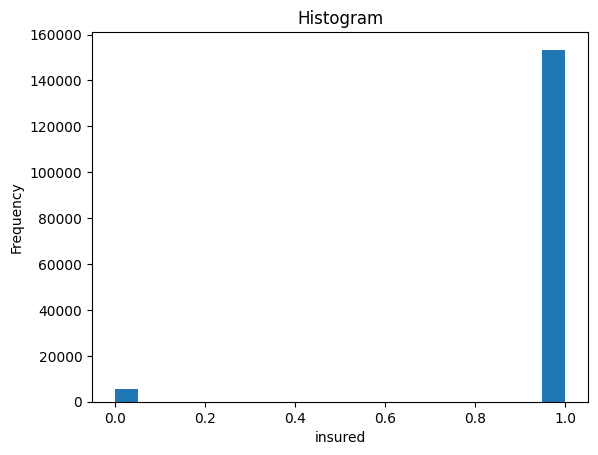

In [24]:
all_merged_data['insured'] = all_merged_data['insured'].replace({'Health Insurance: Yes': 1,
                                                'Health Insurance: No': 0,
                                                'PMI: Prefer Not To Answer': np.nan,
                                                'PMI: Dont Know': np.nan,
                                                'PMI: Skip': np.nan})

# Plot histogram
plt.hist(all_merged_data['insured'], bins='auto')
plt.xlabel('insured')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

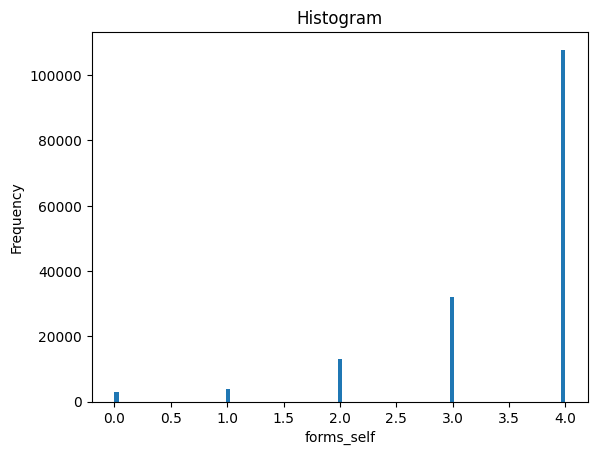

In [25]:
all_merged_data['forms_self'] = all_merged_data['forms_self'].replace({'Medical Form Confidence: Not At All': 0,
                                                'Medical Form Confidence: A Little Bit': 1,
                                                'Medical Form Confidence: Somewhat': 2,
                                                'Medical Form Confidence: Quite A Bit': 3,
                                                 'Medical Form Confidence: Extremely': 4,
                                                'PMI: Skip': np.nan})

# Plot histogram
plt.hist(all_merged_data['forms_self'], bins='auto')
plt.xlabel('forms_self')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

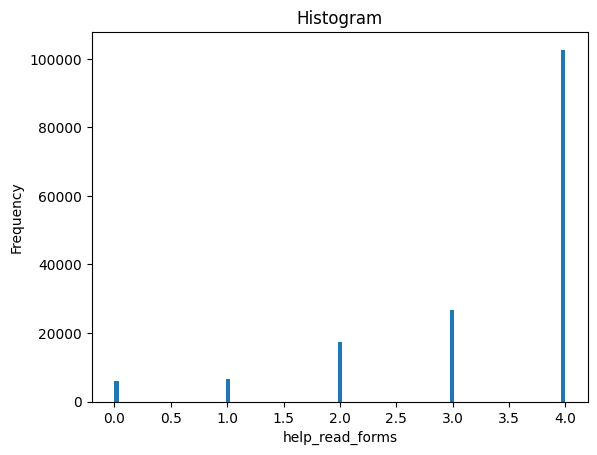

159383

In [26]:
all_merged_data['help_read_forms'] = all_merged_data['help_read_forms'].replace({'Health Material Assistance: Always': 0,
                                                'Health Material Assistance: Often': 1,
                                                'Health Material Assistance: Sometimes': 2,
                                                'Health Material Assistance: Occasionally': 3,
                                                 'Health Material Assistance: Never': 4,
                                                'PMI: Skip': np.nan})

# Plot histogram
plt.hist(all_merged_data['help_read_forms'], bins='auto')
plt.xlabel('help_read_forms')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()
all_merged_data['help_read_forms'].notna().sum()

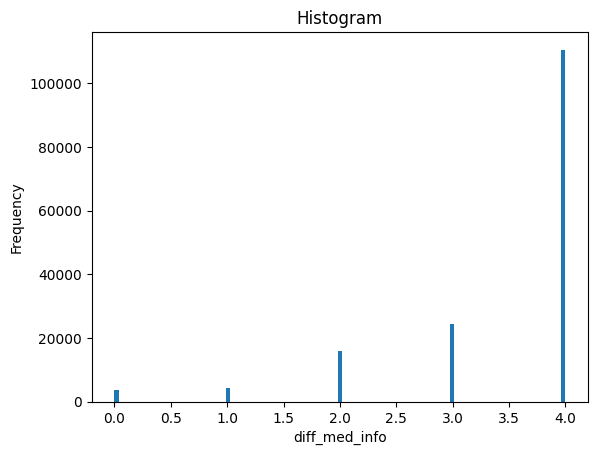

In [27]:
all_merged_data['diff_med_info'] = all_merged_data['diff_med_info'].replace({'Difficult Understand Info: Always': 0,
                                                'Difficult Understand Info: Often': 1,
                                                'Difficult Understand Info: Sometimes': 2,
                                                'Difficult Understand Info: Occasionally': 3,
                                                 'Difficult Understand Info: Never': 4,
                                                'PMI: Skip': np.nan})

# Plot histogram
plt.hist(all_merged_data['diff_med_info'], bins='auto')
plt.xlabel('diff_med_info')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

Cronbach's alpha: 0.75
[0.752 0.756]


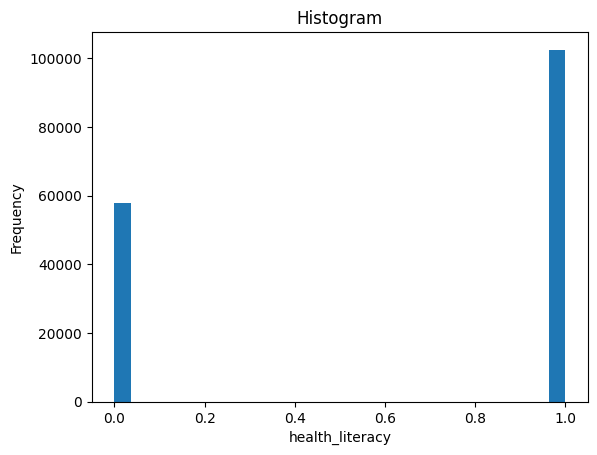

In [28]:
all_merged_data['health_literacy'] = all_merged_data[['forms_self', 'help_read_forms', 'diff_med_info']].mean(axis=1)

# Check if two or more of the three columns are NaN, if so, replace 'health_literacy' with NaN
all_merged_data.loc[all_merged_data[['forms_self', 'help_read_forms', 'diff_med_info']].isnull().sum(axis=1) >= 2, 'health_literacy'] = np.nan

# Specify the columns to calculate Cronbach's alpha on
columns_to_use = ['forms_self', 'help_read_forms', 'diff_med_info']

# Subset the DataFrame to include only the specified columns
df_subset = all_merged_data[columns_to_use]

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

#modify to a binary variable
all_merged_data.loc[all_merged_data['health_literacy'] < 3.5, 'health_literacy'] = 0
all_merged_data.loc[all_merged_data['health_literacy'] >= 3.5, 'health_literacy'] = 1


# Plot histogram
plt.hist(all_merged_data['health_literacy'], bins='auto')
plt.xlabel('health_literacy')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

# Drop the old columns
all_merged_data.drop(['forms_self', 'help_read_forms', 'diff_med_info'], axis=1, inplace=True)




In [29]:
sdoh_survey_df = pd.merge(my_dataframe, sdoh_survey_df, on='person_id', how='inner')


In [30]:
sdoh_survey_df['person_id'].nunique()

72571

In [31]:
# Add a new column 'is_duplicated' to 'sdoh_survey_df' that indicates if a row is duplicated based on 'person_id' and 'question_concept_id', keeping the first occurrence
sdoh_survey_df['is_duplicated'] = sdoh_survey_df.duplicated(subset=['person_id','question_concept_id'], keep='first')

# Display the value counts of 'is_duplicatedl'
print(sdoh_survey_df['is_duplicated'].value_counts())

# Filter 'sdoh_survey_df' for only rows where 'is_duplicated' is False and assign the result to 'demo_long_df'
demo_long_df = sdoh_survey_df[sdoh_survey_df['is_duplicated'] == False]

# Pivot 'demo_long_df' to wide format with 'person_id' as the index, 'question_concept_id' as the columns, and 'answer_concept_id' as the values, assigning the result to 'demo_wide'
demo_wide = demo_long_df.pivot(index='person_id', columns='question_concept_id', values='answer_concept_id')

# Pivot 'demo_long_df' to wide format with 'person_id' as the index, 'question_concept_id' as the columns, and 'answer' as the values, assigning the result to 'demo_wide_text'
demo_wide_text = demo_long_df.pivot(index='person_id', columns='question_concept_id', values='answer')

is_duplicated
False    5645269
True        9123
Name: count, dtype: int64


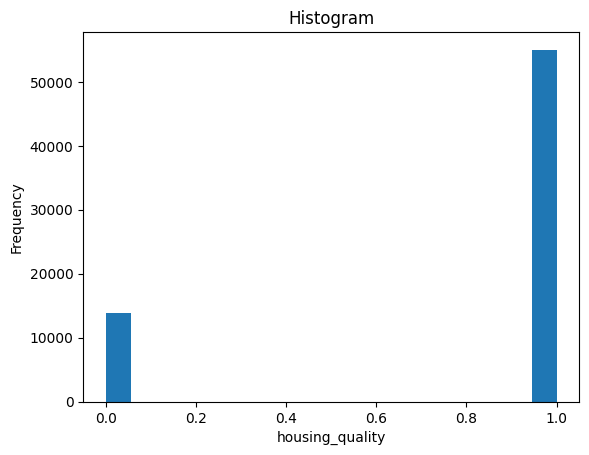

68861

In [32]:
ahc_df = sdoh_survey_df[sdoh_survey_df['question_concept_id']==40192402]

# Creating dummy variables for each unique value in the 'answer' column. 
# The prefix 'ahc' is added to the name of each new dummy variable.
dummies = pd.get_dummies(ahc_df['answer'], prefix='ahc')

# Concatenating the dummy variables with the original DataFrame.
ahc_df = pd.concat([ahc_df, dummies], axis=1)

# Grouping by 'person_id' and aggregating certain fields by sum.
# reset_index() is used to avoid 'person_id' becoming the index of the DataFrame.
ahc_df = ahc_df.groupby('person_id')[
    ['ahc_Bug infestation', 'ahc_Inadequate heat', 'ahc_Lead paint or pipes', 'ahc_Mold',
     'ahc_No or not working smoke detector', 'ahc_Oven or stove not working', 'ahc_Water leaks', 
     'ahc_PMI: Skip', 'ahc_None of the above']
].sum().reset_index()

# Creating a new field 'ahc_scale' by summing across specific fields for each 'person_id'.
ahc_df['ahc_scale'] = ahc_df[
    ['ahc_Bug infestation', 'ahc_Inadequate heat', 'ahc_Lead paint or pipes', 'ahc_Mold',
     'ahc_No or not working smoke detector', 'ahc_Oven or stove not working','ahc_Water leaks']
].sum(axis=1)

# Creating a new binary field 'ahc_binary' based on conditions applied on 'ahc_None of the above' and 'ahc_scale'.
ahc_df['housing_quality'] = np.where(
    (ahc_df['ahc_None of the above'] == 0) & (ahc_df['ahc_scale'] == 0), np.nan, 
    np.where(ahc_df['ahc_None of the above'] == 1, 1,
             np.where(ahc_df['ahc_scale'] > 0, 0, np.nan))
)


# Selecting only specific fields from 'ahc_df'.
ahc_df = ahc_df[['person_id', 'housing_quality']]

all_merged_data = pd.merge(all_merged_data, ahc_df, on='person_id', how='left')

# Plot histogram
plt.hist(all_merged_data['housing_quality'], bins='auto')
plt.xlabel('housing_quality')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()
all_merged_data['housing_quality'].notna().sum()

/tmp/ipykernel_105/1455597682.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  urs_df['urs_scale'] = urs_df['answer']
/tmp/ipykernel_105/1455597682.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  urs_df['urs_scale'] = urs_df['urs_scale'].replace({'0': 0, 'PMI: Skip': np.nan})
/tmp/ipykernel_105/1455597682.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

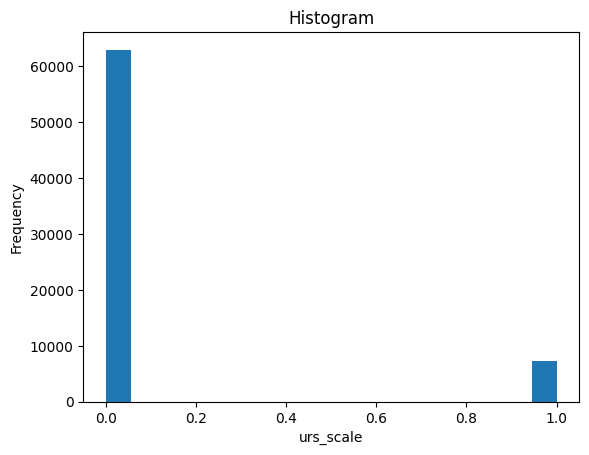

91821

In [33]:
# housing relocations in the past 12 months.

urs_df=sdoh_survey_df[sdoh_survey_df['question_concept_id']==40192441]

# Creating a new column 'urs_scale' by copying the 'answer' column
urs_df['urs_scale'] = urs_df['answer']

# Recoding 'urs_scale' to convert '0' to 0 and 'PMI: Skip' to NaN
urs_df['urs_scale'] = urs_df['urs_scale'].replace({'0': 0, 'PMI: Skip': np.nan})

# Filling missing values (NaN) in 'urs_scale' with a placeholder value (-1)
urs_df['urs_scale'] = urs_df['urs_scale'].fillna(-1)

# Converting 'urs_scale' to numeric type
urs_df['urs_scale'] = pd.to_numeric(urs_df['urs_scale'])

# Recoding 'urs_scale' to 1 for values > 0, 0 for values = 0, and NaN for missing values
urs_df['urs_scale'] = np.where(urs_df['urs_scale'] > 0, 1, np.where(urs_df['urs_scale'] == 0, 0, np.nan))

# Selecting only specific columns from 'urs_df'
urs_df = urs_df[['person_id', 'urs_scale']]

all_merged_data = pd.merge(all_merged_data, urs_df, on='person_id', how='left')

# Plot histogram
plt.hist(all_merged_data['urs_scale'], bins='auto')
plt.xlabel('urs_scale')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()
all_merged_data['urs_scale'].isna().sum()

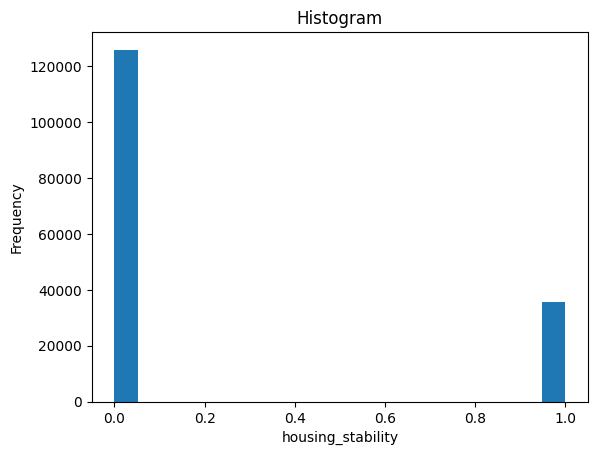

578

In [34]:
# Create a new column 'housing_stability'
all_merged_data['housing_stability'] = np.nan

# Check conditions and assign values
all_merged_data['housing_stability'] = np.where(
    (all_merged_data['worried_living'] == 1) | (all_merged_data['years_living'] == 1),
    1,  # If either column has a 1, assign 1
    np.where(
        (all_merged_data['worried_living'] == 0) | (all_merged_data['years_living'] == 0),
        0,  # If either column has a 0, assign 0
        np.nan  # Otherwise, assign NaN
    )
)

# Plot histogram
plt.hist(all_merged_data['housing_stability'], bins='auto')
plt.xlabel('housing_stability')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()
all_merged_data['housing_stability'].isna().sum()

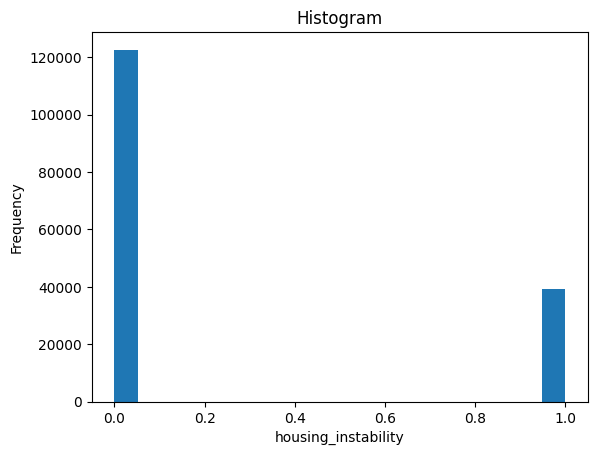

Cronbach's alpha: 0.81
[0.81  0.813]


In [35]:
# Create a new column 'housing_stability'
all_merged_data['housing_instability'] = np.nan

# Check conditions and assign values
all_merged_data['housing_instability'] = np.where(
    (all_merged_data['housing_stability'] == 1) | (all_merged_data['urs_scale'] == 1),
    1,  # If either column has a 1, assign 1
    np.where(
        (all_merged_data['housing_stability'] == 0) | (all_merged_data['urs_scale'] == 0),
        0,  # If either column has a 0, assign 0
        np.nan  # Otherwise, assign NaN
    )
)

# Plot histogram
plt.hist(all_merged_data['housing_instability'], bins='auto')
plt.xlabel('housing_instability')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

# Specify the columns to calculate Cronbach's alpha on
columns_to_use = ['worried_living', 'years_living', 'housing_stability']

# Subset the DataFrame to include only the specified columns
df_subset = all_merged_data[columns_to_use]

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

all_merged_data.drop(['worried_living', 'years_living'], axis=1, inplace=True)
all_merged_data.drop(['housing_stability', 'urs_scale'], axis=1, inplace=True)

In [36]:
hvs_df = sdoh_survey_df[(sdoh_survey_df['question_concept_id'] == 40192517) | (sdoh_survey_df['question_concept_id'] == 40192426)]

# Recoding the answers for the questions related to food insecurity
# '40192508' and '40192488' codes mean insecurity, thus recoded to 1
# '40192474' means security, thus recoded to 0
# '903087' and '903096' mean respondent skipped, thus recoded to NaN

hvs_df['food_insecurity'] = np.where(
    (hvs_df['answer_concept_id'] == 40192508) | (hvs_df['answer_concept_id'] == 40192488),
    1,  
    np.where(
        (hvs_df['answer_concept_id'] == 40192474),
        0,  # If either column has a 0, assign 1
        np.nan  # Otherwise, assign NaN
    )
)

hvs_df.drop_duplicates(subset='person_id', inplace=True)
hvs_df = hvs_df[['person_id', 'food_insecurity']]

all_merged_data = pd.merge(all_merged_data, hvs_df, on='person_id', how='left')



/tmp/ipykernel_105/3586722425.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hvs_df['food_insecurity'] = np.where(
/tmp/ipykernel_105/3586722425.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hvs_df.drop_duplicates(subset='person_id', inplace=True)


In [37]:
subset = sdoh_survey_df[(sdoh_survey_df['question_concept_id'] == 40192517) | (sdoh_survey_df['question_concept_id'] == 40192426)]
subset_df = subset.pivot(index='person_id', columns='question_concept_id', values='answer_concept_id')
subset_df

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=subset_df)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

Cronbach's alpha: 0.86
[0.857 0.862]


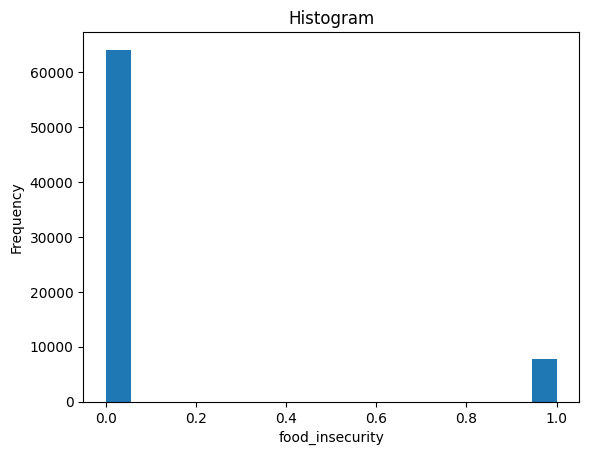

90451

In [38]:
# Plot histogram
plt.hist(all_merged_data['food_insecurity'], bins='auto')
plt.xlabel('food_insecurity')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()
all_merged_data['food_insecurity'].isna().sum()

In [39]:
check=sdoh_survey_df[sdoh_survey_df['question_concept_id']==40192492]
unique_answers = check.drop_duplicates(subset='answer_concept_id')
print(check['question'].unique())
print(unique_answers[['answer_concept_id', 'answer']])


['The crime rate in my neighborhood makes it unsafe to go on walks at night. Would you say that you...']
      answer_concept_id             answer
70             40192514     Strongly agree
146            40192478     Somewhat agree
224            40192422  Strongly disagree
302              903096          PMI: Skip
380            40192527  Somewhat disagree
1469             903087     PMI: Dont Know


In [40]:
# Copying columns with question concept id 40192431 and 40192437 into columns with new ids 140192431 and 140192437 respectively
demo_wide[140192431] = demo_wide[40192431] 
demo_wide[140192437] = demo_wide[40192437]

In [41]:
# Defining column lists for various scales used in the survey data
# Each list corresponds to a particular scale and contains question ids pertaining to that scale
# The names of these lists (like uls_cols, panes_cols, etc.) correspond to the scale they represent

uls_cols = [ 40192507,  40192397 ,  40192504 ,  40192398 ,  40192501 ,  40192516 ,  40192390 ,  40192494 ]
panes_cols = [ 40192436 ,  40192440 ,  40192437 ,  40192431 ,  40192410 ]
panecr_cols =[ 40192492 ,  40192414 ]
npd_cols = [  40192420 ,  40192522 ,  40192412 ,  40192469 ,  40192456 ,  40192386 ]
nsd_cols = [ 40192500 ,  40192493 ,  40192457 ,  40192476 ,  40192404 ,  40192400 ,  40192384 ]
eds_cols =[ 40192466 ,  40192489 ,  40192416 ,  40192490 ,  40192380 , 40192395 ,  40192496 ,  40192519 ,  40192451 ]
dms_cols = [ 40192497 ,  40192425 ,  40192503 ,  40192505 ,  40192423 ,  40192394 ,  40192383 ]
scns_cols = [ 40192463 ,  40192411 ,  40192499 ,  40192417 ]
cpss_cols = [ 40192452 ,  40192381 ,  40192491 , 40192419 , 40192525 , 40192506 , 40192449 , 40192445 , 40192396 ,  40192462 ]
moss1_cols =[ 40192442 ,  40192480 ,  40192388 ,  40192511  ]
moss2_cols =[ 40192439 ,  40192528 ,  40192399 ,  40192446  ]
moss_cols = [ 40192439 ,  40192528 ,  40192399 ,  40192446 ,  40192442 ,  40192480 ,  40192388 ,  40192511 ]
dse_cols = [ 40192498 ,  40192475 ,  40192401 ,  40192443 ,  40192471 ,  40192415]

# Defining recoding dictionaries
# These dictionaries map the original coded answers to a new set of codes
# Each dictionary corresponds to a particular scale in the survey data
# The names of these dictionaries (like recode_hvs, reverse_uls, etc.) correspond to the scale they are used for
# Keys are the original codes and values
recode_hvs={40192508:1, 40192488:1, 40192474:0, 903087:np.nan, 903096:np.nan}
reverse_uls={40192465:4, 40192481:3, 40192429:2, 40192482:1, 903087:np.nan, 903096:np.nan}
recoding_uls={40192465:1, 40192481:2, 40192429:3, 40192482:4, 903087:np.nan, 903096:np.nan}
panes_recode = {40192514:4, 40192478:3, 40192527:2, 40192422:1, 40192520:1, 903087:np.nan, 903096:np.nan}
panes_reverse = {40192514:1, 40192478:2, 40192527:3, 40192422:4, 40192520:4, 903087:np.nan, 903096:np.nan}
npd_reverse = {40192514:1, 40192455:2, 40192408:3, 40192422:4, 903087:np.nan, 903096:np.nan}
npd_recode = {40192514:4, 40192455:3, 40192408:2, 40192422:1, 903087:np.nan, 903096:np.nan}
nsd_reverse = {40192514:1, 40192455:2, 40192408:3, 40192422:4, 903087:np.nan, 903096:np.nan}
nsd_recode = {40192422:1,40192408:2,40192455:3,40192514:4,903087:np.nan, 903096:np.nan}
eds_recode = {40192465:0, 40192464:1, 40192453:2, 40192461:3, 40192391:4, 40192421:5, 903087:np.nan, 903096:np.nan}
scns_recode = {40192422:1, 40192408:2, 40192524:3, 40192455:4, 40192514:5, 903087:np.nan, 903096:np.nan}
cpss_reverse= {40192424:1, 40192477:2, 40192429:3, 40192430:4, 40192465:5, 903087:np.nan, 903096:np.nan}
cpss_recode = {40192465:1, 40192430:2, 40192429:3, 40192477:4, 40192424:5, 903087:np.nan, 903096:np.nan}
moss_recode = {40192454:1, 40192518:2, 40192486:3, 40192382:4, 40192521:5, 903087:np.nan, 903096:np.nan}
dse_recode = {40192487:0, 40192432:0, 40192403:6, 40192385:5, 40192484:4, 40192513:2, 40192459:1, 40192509:6,903087:np.nan, 903096:np.nan}
dms_recode = {40192465 :1,  40192481 :2, 40192429 :3 ,40192382 :4 , 40192515 :5 ,903087 :np.nan ,903096	:np.nan }

# Recoding variables in the 'demo_wide' dataframe
# Each question ID is replaced by its corresponding recode mapping 
# Question concept IDs in the dataframe are used as keys in the replacement dictionary
# The replacement is done in place, updating the 'demo_wide' dataframe

demo_wide = demo_wide.replace({40192517:recode_hvs, 40192426:recode_hvs, 40192507:recoding_uls, 40192397:recoding_uls,
                                 40192504:reverse_uls, 40192398:recoding_uls, 40192501:recoding_uls,
                                 40192516:reverse_uls,40192390:recoding_uls, 40192494:recoding_uls,40192436:panes_recode,
                                 40192440:panes_recode, 40192437:panes_recode, 40192431:panes_recode, 40192410:panes_recode,
                                 40192492:panes_recode, 40192414:panes_recode, 
                               40192420:npd_recode, 40192522:npd_recode,
                                 40192412:npd_recode, 40192469:npd_recode, 40192456:npd_reverse,
                                 40192386:npd_reverse,40192500:nsd_recode, 40192493:nsd_recode, 40192457:nsd_recode,
                                 40192476:nsd_recode, 40192404:nsd_recode, 40192400:nsd_reverse,
                                 40192384:nsd_reverse,40192466:eds_recode, 40192489:eds_recode, 40192416:eds_recode,
                                 40192490:eds_recode, 40192380:eds_recode, 40192395:eds_recode, 40192496:eds_recode,
                                 40192519:eds_recode, 40192451:eds_recode,40192463:scns_recode, 40192411:scns_recode,
                                 40192499:scns_recode, 40192417:scns_recode,40192419:cpss_reverse, 40192525:cpss_reverse,
                                 40192449:cpss_reverse, 40192445:cpss_reverse, 40192452:cpss_recode, 40192381:cpss_recode,
                                 40192491:cpss_recode, 40192506:cpss_recode, 40192396:cpss_recode,
                                 40192462:cpss_recode,40192439:moss_recode, 40192528:moss_recode, 40192399:moss_recode,
                                 40192446:moss_recode, 40192442:moss_recode, 40192480:moss_recode, 40192388:moss_recode,
                                 40192511:moss_recode,40192498:dse_recode, 40192475:dse_recode, 40192401:dse_recode,
                                 40192443:dse_recode, 40192471:dse_recode, 40192415:dse_recode,
                               40192497 :dms_recode ,   40192425 :dms_recode ,   40192503 :dms_recode ,  
                               40192505 :dms_recode ,   40192423 :dms_recode ,   40192394 :dms_recode ,   
                               40192383 :dms_recode})

Cronbach's alpha: 0.78
[0.775 0.78 ]


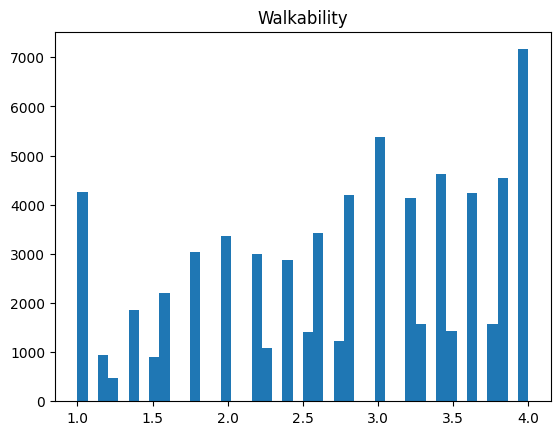

93337

In [42]:
# Walkability

# Define question concept IDs for PANES related questions
panes_cols = [ 40192436 ,  40192440 ,  40192437 ,  40192431 ,  40192410 ]

#Subset data to only rows where there is no more than 1 null value for panes_cols and then average the panes_cols
panes_subset = demo_wide[demo_wide[panes_cols].isnull().sum(axis=1) <= 1].assign(Walkability=lambda df: df[panes_cols].mean(axis=1))

#Add scale column of interest back to our main df
all_merged_data = pd.merge(all_merged_data, panes_subset['Walkability'], on='person_id', how='left')

# Specify the columns to calculate Cronbach's alpha on
columns_to_use = [40192436 ,  40192440 ,  40192437 ,  40192431 ,  40192410]

# Subset the DataFrame to include only the specified columns
df_subset = panes_subset[columns_to_use]

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

# Descriptive statistics for scale
#print(all_merged_data['Walkability'].describe())

# Plot histogram
plt.hist(all_merged_data['Walkability'], bins='auto')
plt.title('Walkability')
plt.show()
all_merged_data['Walkability'].isna().sum()

Cronbach's alpha: 0.87
[0.867 0.87 ]
count    70411.000000
mean        29.845961
std         21.640974
min          0.000000
25%         12.500000
50%         25.000000
75%         45.833333
max        100.000000
Name: loneliness, dtype: float64


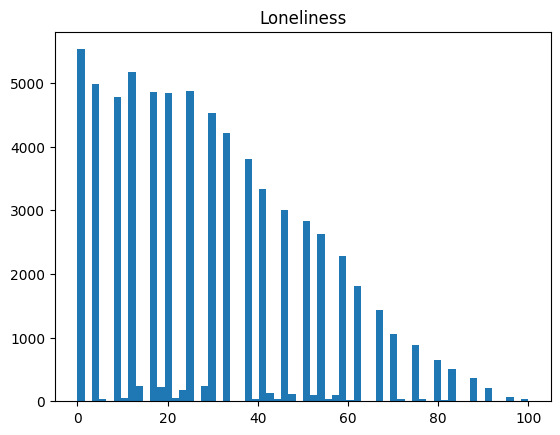

91782

In [43]:
#Loneliness

#Subset data to only rows where there is no more than 2 null value for uls_cols and then average the uls_cols
uls_subset = demo_wide[demo_wide[uls_cols].isnull().sum(axis=1) <= 2].assign(loneliness=lambda df: df[uls_cols].mean(axis=1))

# Rescale 'uls_scale' to range 0-100
uls_subset['loneliness'] = (uls_subset['loneliness'] - uls_subset['loneliness'].min()) / (uls_subset['loneliness'].max() - uls_subset['loneliness'].min()) * 100

#Add scale column of interest back to our main df
all_merged_data = pd.merge(all_merged_data, uls_subset['loneliness'], on='person_id', how='left')

# Subset the DataFrame to include only the specified columns
df_subset = uls_subset[uls_cols]

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

# Descriptive statistics for scale
print(all_merged_data['loneliness'].describe())

# Plot histogram
plt.hist(all_merged_data['loneliness'], bins='auto')
plt.title('Loneliness')
plt.show()
all_merged_data['loneliness'].isna().sum()

Cronbach's alpha: 0.77
[0.763 0.77 ]
count    62989.000000
mean         1.467653
std          0.700411
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: crime_saftey, dtype: float64


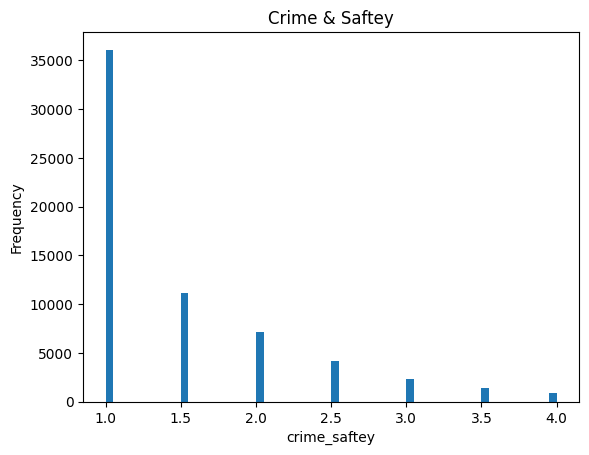

99204

In [44]:
# 'panescr' (PANES - Crime and safety) related questions

#Subset data to only rows where there is no null value for panescr_cols and then average the panescr_cols
panescr_subset = demo_wide[demo_wide[panecr_cols].isnull().sum(axis=1) == 0].assign(crime_saftey=lambda df: df[panecr_cols].mean(axis=1))

#Add scale column of interest back to our main df
all_merged_data = pd.merge(all_merged_data, panescr_subset['crime_saftey'], on='person_id', how='left')

# Subset the DataFrame to include only the specified columns
df_subset = panescr_subset[panecr_cols]

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

# Descriptive statistics for scale
print(all_merged_data['crime_saftey'].describe())

# Plot histogram
plt.hist(all_merged_data['crime_saftey'], bins='auto')
plt.xlabel('crime_saftey')
plt.ylabel('Frequency')
plt.title('Crime & Saftey')
plt.show()
all_merged_data['crime_saftey'].isna().sum()

Cronbach's alpha: 0.84
[0.834 0.838]
count    70040.000000
mean         1.598678
std          0.562923
min          1.000000
25%          1.166667
50%          1.500000
75%          2.000000
max          4.000000
Name: npd_scale, dtype: float64


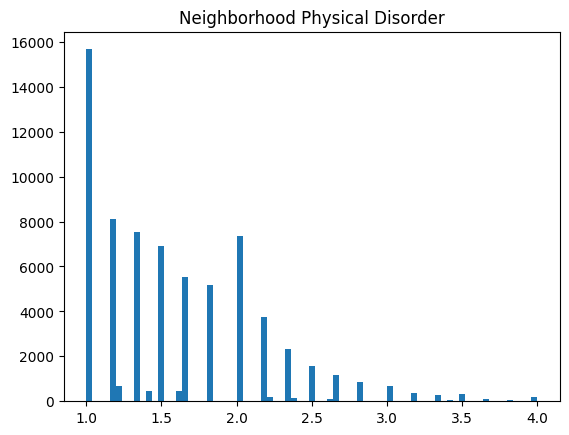

92153

In [45]:
#'npd' (Neighborhood physical disorder) related questions

#Subset data to only rows where there is more than 1 null value for npd_cols and then average the npd_cols
npd_subset = demo_wide[demo_wide[npd_cols].isnull().sum(axis=1) <= 1].assign(npd_scale=lambda df: df[npd_cols].mean(axis=1))

#Add scale column of interest back to our main df
all_merged_data = pd.merge(all_merged_data, npd_subset['npd_scale'], on='person_id', how='left')

# Subset the DataFrame to include only the specified columns
df_subset = npd_subset[npd_cols]

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

# Descriptive statistics for scale
print(all_merged_data['npd_scale'].describe())

# Plot histogram
plt.hist(all_merged_data['npd_scale'], bins='auto')
plt.title('Neighborhood Physical Disorder')
plt.show()
all_merged_data['npd_scale'].isna().sum()

Cronbach's alpha: 0.87
[0.872 0.875]
count    68183.000000
mean         1.607631
std          0.534935
min          1.000000
25%          1.142857
50%          1.428571
75%          2.000000
max          4.000000
Name: nsd_scale, dtype: float64


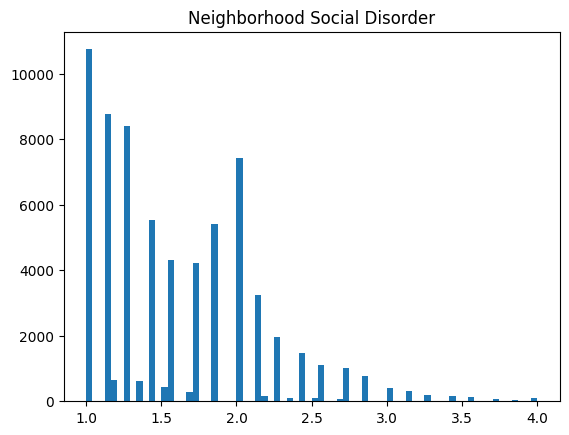

94010

In [46]:
#'nsd' (Neighborhood social disorder) related questions

#Subset data to only rows where there is more than 1 null value for nsd_cols and then average the nsd_cols
nsd_subset = demo_wide[demo_wide[nsd_cols].isnull().sum(axis=1) <= 1].assign(nsd_scale=lambda df: df[nsd_cols].mean(axis=1))

#Add scale column of interest back to our main df
all_merged_data = pd.merge(all_merged_data, nsd_subset['nsd_scale'], on='person_id', how='left')

# Subset the DataFrame to include only the specified columns
df_subset = nsd_subset[nsd_cols]

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

# Descriptive statistics for scale
print(all_merged_data['nsd_scale'].describe())

# Plot histogram
plt.hist(all_merged_data['nsd_scale'], bins='auto')
plt.title('Neighborhood Social Disorder')
plt.show()
all_merged_data['nsd_scale'].isna().sum()

Cronbach's alpha: 0.91
[0.908 0.91 ]
count    69965.000000
mean         0.766558
std          0.812347
min          0.000000
25%          0.111111
50%          0.555556
75%          1.111111
max          5.000000
Name: discrimination, dtype: float64


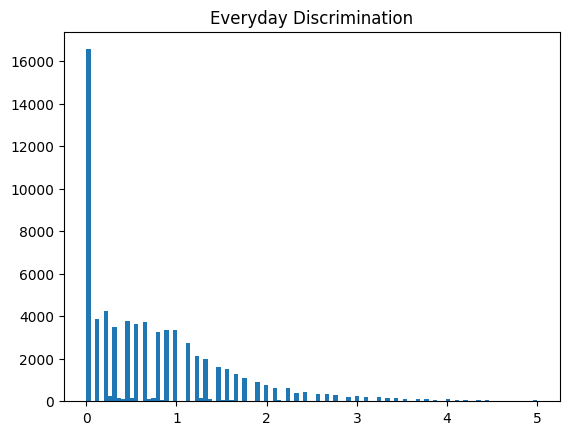

92228

In [47]:
#'eds'(Everyday discrimination) questions

#Subset data to only rows where there is more than 2 null value for eds_cols and then average the eds_cols
eds_subset = demo_wide[demo_wide[eds_cols].isnull().sum(axis=1) <= 2].assign(discrimination=lambda df: df[eds_cols].mean(axis=1))

#Add scale column of interest back to our main df
all_merged_data = pd.merge(all_merged_data, eds_subset['discrimination'], on='person_id', how='left')

# Subset the DataFrame to include only the specified columns
df_subset = eds_subset[eds_cols]

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

# Descriptive statistics for scale
print(all_merged_data['discrimination'].describe())

# Plot histogram
plt.hist(all_merged_data['discrimination'], bins='auto')
plt.title('Everyday Discrimination')
plt.show()
all_merged_data['discrimination'].isna().sum()

Cronbach's alpha: 0.90
[0.896 0.898]
count    70630.000000
mean         1.545385
std          0.634557
min          1.000000
25%          1.000000
50%          1.285714
75%          1.857143
max          5.000000
Name: health_discrim, dtype: float64


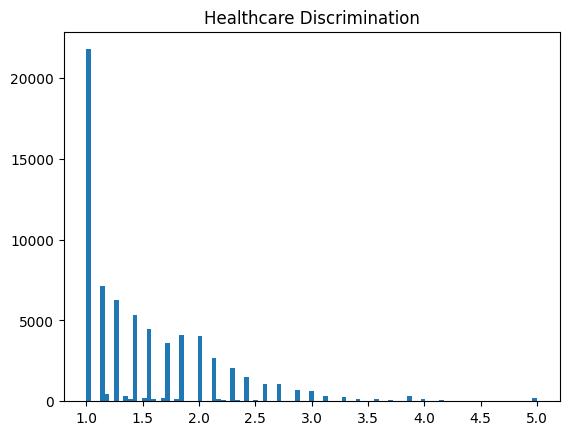

91563

In [48]:
#'dms' (Discrimination in health care settings) related questions

#Subset data to only rows where there is more than 2 null value for dms_cols and then average the dms_cols
dms_subset = demo_wide[demo_wide[dms_cols].isnull().sum(axis=1) <= 2].assign(health_discrim=lambda df: df[dms_cols].mean(axis=1))

#Add scale column of interest back to our main df
all_merged_data = pd.merge(all_merged_data, dms_subset['health_discrim'], on='person_id', how='left')

# Subset the DataFrame to include only the specified columns
df_subset = dms_subset[dms_cols]

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

# Descriptive statistics for scale
print(all_merged_data['health_discrim'].describe())

# Plot histogram
plt.hist(all_merged_data['health_discrim'], bins='auto')
plt.title('Healthcare Discrimination')
plt.show()
all_merged_data['health_discrim'].isna().sum()

Cronbach's alpha: 0.88
[0.874 0.877]
count    70569.000000
mean         3.836407
std          0.737291
min          1.000000
25%          3.500000
50%          3.750000
75%          4.250000
max          5.000000
Name: social_cohesion, dtype: float64


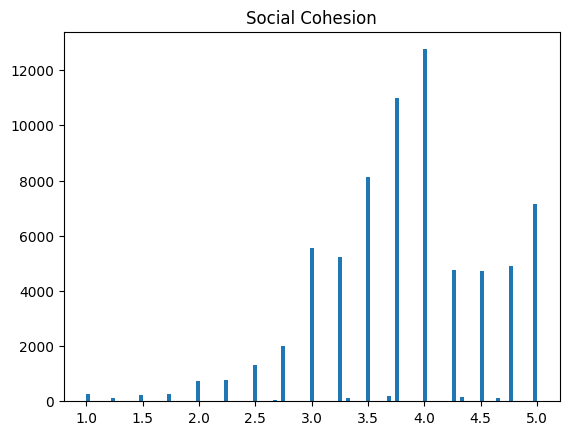

91624

In [49]:
# neighborhood social cohesion related columns

#Subset data to only rows where there is more than 1 null value for scns_cols and then average the scns_cols
scns_subset = demo_wide[demo_wide[scns_cols].isnull().sum(axis=1) <= 1].assign(social_cohesion=lambda df: df[scns_cols].mean(axis=1))

#Add scale column of interest back to our main df
all_merged_data = pd.merge(all_merged_data, scns_subset['social_cohesion'], on='person_id', how='left')

# Subset the DataFrame to include only the specified columns
df_subset = scns_subset[scns_cols]

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

# Descriptive statistics for scale
print(all_merged_data['social_cohesion'].describe())

# Plot histogram
plt.hist(all_merged_data['social_cohesion'], bins='auto')
plt.title('Social Cohesion')
plt.show()
all_merged_data['social_cohesion'].isna().sum()

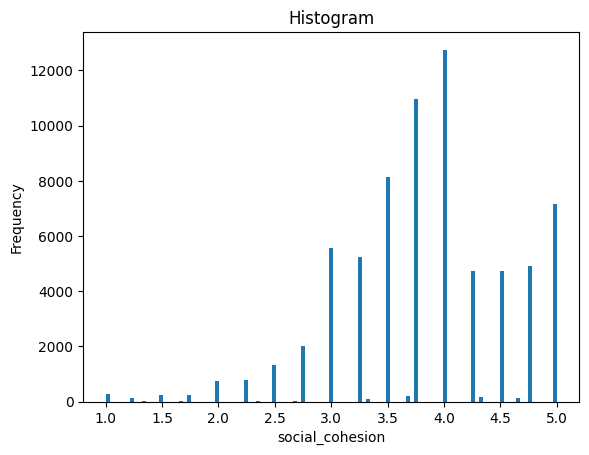

In [50]:
# Plot histogram
plt.hist(all_merged_data['social_cohesion'], bins='auto')
plt.xlabel('social_cohesion')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

Cronbach's alpha: 0.90
[0.901 0.903]
count    67927.000000
mean        23.283196
std          7.758787
min         10.000000
25%         17.000000
50%         23.000000
75%         29.000000
max         50.000000
Name: stress, dtype: float64


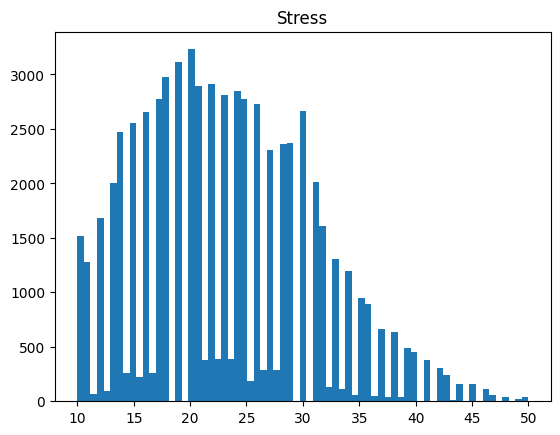

94266

In [51]:
# perceived stress related columns

#Subset data to only rows where there is no more than 2 null value for cpss_cols and then average the cpss_cols
cpss_subset = demo_wide[demo_wide[cpss_cols].isnull().sum(axis=1) <= 2].assign(stress=lambda df: df[cpss_cols].mean(axis=1))

#multiply item mean by 10
cpss_subset['stress'] = cpss_subset['stress']*10

#Add scale column of interest back to our main df
all_merged_data = pd.merge(all_merged_data, cpss_subset['stress'], on='person_id', how='left')

# Subset the DataFrame to include only the specified columns
df_subset = cpss_subset[cpss_cols]

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

# Descriptive statistics for 'uls' scale
print(all_merged_data['stress'].describe())

# Plot histogram
plt.hist(all_merged_data['stress'], bins='auto')
plt.title('Stress')
plt.show()
all_merged_data['stress'].isna().sum()

Cronbach's alpha: 0.95
[0.948 0.949]
count    69331.000000
mean         3.913441
std          1.028507
min          1.000000
25%          3.250000
50%          4.125000
75%          4.875000
max          5.000000
Name: social_support, dtype: float64


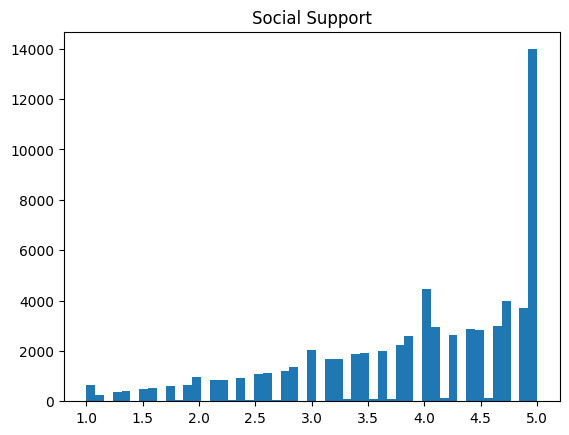

In [52]:
#social support related columns

#Subset data to only rows where there is more than 1 null value for moss_cols and then average the moss_cols
moss_subset = demo_wide[demo_wide[moss_cols].isnull().sum(axis=1) <= 1].assign(social_support=lambda df: df[moss_cols].mean(axis=1))

#Add scale column of interest back to our main df
all_merged_data = pd.merge(all_merged_data, moss_subset['social_support'], on='person_id', how='left')

# Subset the DataFrame to include only the specified columns
df_subset = moss_subset[moss_cols]

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

# Descriptive statistics for 'uls' scale
print(all_merged_data['social_support'].describe())

# Plot histogram
plt.hist(all_merged_data['social_support'], bins='auto')
plt.title('Social Support')
plt.show()


In [53]:
# SQL query to fetch SDOHR survey data from BigQuery

df = pd.read_gbq(f"""
        SELECT DISTINCT person_id, concept_name as question, value_source_value,value_as_concept_id ,value_as_string,
         DATE(observation_date) as survey_date
        FROM   `""" + os.environ["WORKSPACE_CDR"] + """.observation`
        JOIN   `""" + os.environ["WORKSPACE_CDR"] + """.concept` on concept_id = observation_source_concept_id
        WHERE observation_source_concept_id  IN (
                SELECT distinct concept_id_2
                FROM  `""" + os.environ["WORKSPACE_CDR"] + """.concept_relationship` 
                where concept_id_1  = 40192389 #Social Determinants of Health           
                and relationship_id = 'PPI parent code of'
                    )
        AND observation_source_concept_id = 40192470
       
        
        """)
    
n = df.person_id.nunique()
df['value_as_string'].value_counts()

sdohr_survey_sql = """SELECT 
        answer.person_id, answer.question_concept_id,answer.question, 
        answer.answer_concept_id, answer.answer, answer.survey_datetime,
    FROM  `""" + os.environ["WORKSPACE_CDR"] + """.ds_survey` answer   
    WHERE(question_concept_id IN (40192470))"""

sdohr_survey_df = pd.read_gbq(sdohr_survey_sql, dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),progress_bar_type="tqdm_notebook")
relattend = sdohr_survey_df[sdohr_survey_df['question_concept_id'] == 40192470][['person_id', 'survey_datetime', 'answer_concept_id', 'answer']]

df_merged=pd.merge(relattend,df,on='person_id')

# Mapping for answer concept IDs to answer labels
answer_mappings = {
    903096: 'PMI: Skip',
    4052938: 'I am not religious',
    37079286: 'More than once a week',
    42531017: 'Once a week',
    45882429: '1 to 3 times per month',
    45882527: 'Never or almost never',
    45883171: 'Less than once per month',
    2000000010: 'Incorrect'
}

# Convert 'value_as_concept_id' column to string type
df_merged['value_as_concept_id'] = df_merged['value_as_concept_id'].astype(str)

# Replace answer concept IDs with answer labels in df_merged
df_merged['value_as_concept_id'] = df_merged['value_as_concept_id'].replace(answer_mappings)


Downloading:   0%|          | 0/259189 [00:00<?, ?rows/s]

In [54]:
# Create 'ra_na' column indicating if the answer is 'PMI: Skip' or null
df_merged['ra_na'] = df_merged['value_as_concept_id'].apply(lambda x: 1 if x == 'PMI: Skip' or  pd.isnull(x) else 0)
# Create 'incorrect' column indicating if the answer is 'Incorrect'
df_merged['incorrect'] = df_merged['value_as_concept_id'].apply(lambda x: 1 if x == 'Incorrect' else 0)
df_merged['value_as_concept_id'].value_counts()
df_merged_df = df_merged[['person_id', 'ra_na','incorrect']]

df_merged_df['ra_na'].value_counts()

df_merged_df['incorrect'].value_counts()



# Merge df_merged_df with bdemo_wide DataFrame on 'person_id'
demo_wide = pd.merge(df_merged_df, demo_wide, on='person_id')

Cronbach's alpha: 0.83
[0.829 0.832]
count    71638.000000
mean         3.556701
std          1.584710
min          0.000000
25%          2.166667
50%          3.666667
75%          5.000000
max          6.000000
Name: spirituality, dtype: float64


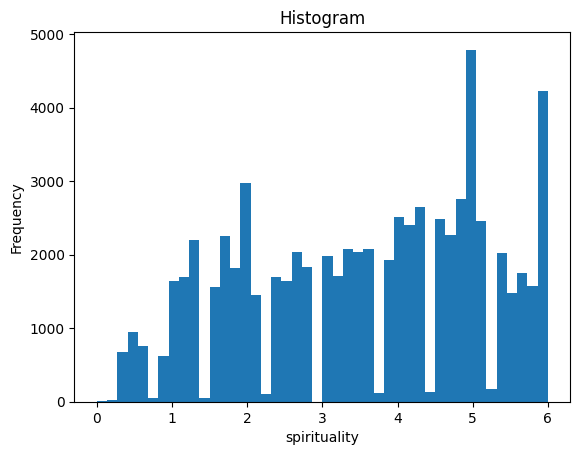

90555

In [55]:
# Calculate the number of null values per row in the daily spiritual experiences related columns
demo_wide['dse_null'] = demo_wide[dse_cols].isnull().sum(axis=1)

# Convert daily spiritual experiences related columns to numeric type
demo_wide[dse_cols] = demo_wide[dse_cols].apply(pd.to_numeric, errors='coerce')

# Create a new binary column, dse_na, that flags rows with more than 2 null values in the daily spiritual experiences related questions
demo_wide['dse_na'] = demo_wide['dse_null'].apply(lambda x: 1 if x > 2 else 0)

# Compute the average of the daily spiritual experiences related questions for rows with no null values in these questions
demo_wide['spirituality'] = demo_wide[demo_wide['dse_na'] == 0][dse_cols].mean(axis=1)

# Subset of data without nulls in 'dse' questions
dse_subset = demo_wide[demo_wide['dse_null'] <= 2]
dse_subset = dse_subset[['person_id', 'spirituality']]

all_merged_data = pd.merge(all_merged_data, dse_subset, on='person_id', how='left')

# Subset the DataFrame to include only the specified columns
df_subset = demo_wide[dse_cols]

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

# Descriptive statistics for 'uls' scale
print(all_merged_data['spirituality'].describe())

# Plot histogram
plt.hist(all_merged_data['spirituality'], bins='auto')
plt.xlabel('spirituality')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()
all_merged_data['spirituality'].isna().sum()

In [56]:
all_merged_data.isna().sum()/len(all_merged_data)*100

person_id               0.000000
date_of_birth           0.000000
AIAN                    0.000000
Asian                   0.000000
Black                   0.000000
Mid                     0.000000
Multiple                0.000000
PI                      0.000000
White                   0.000000
His                     0.000000
race_unknown            0.000000
SexGender               0.000000
age_today               0.000000
where_born              0.000000
military                0.067820
healthcare             14.630718
disabled                0.000000
sexual_orientation      0.000000
LGBTQIA                 0.000000
min_date                0.000000
max_date                0.000000
ehr_length              0.000000
relative_health         0.000000
record_depth            0.000000
visit_frequency         0.000000
age_at_last_event       0.000000
education               2.244240
employment              2.543883
income                 17.686953
home_own                3.472406
insured   

# Make HCAU variables

In [57]:
hcau = pd.merge(all_merged_data, survey_df_2, on='person_id', how='left')

/tmp/ipykernel_105/1283719462.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  insurance['insurance_accepted'] = np.where(


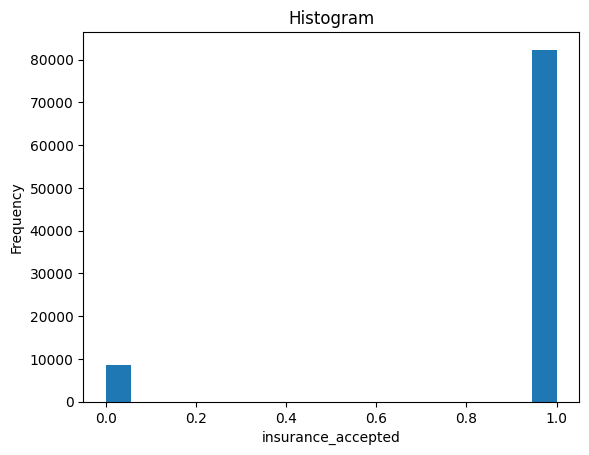

In [58]:
insurance=hcau[hcau['question_concept_id']==43530418]
insurance[['answer_concept_id', 'answer']].drop_duplicates()

insurance['insurance_accepted'] = np.where(
    (insurance['answer'] == 'Insurance Accepted: No'), 1, 
    np.where(insurance['answer'] == 'Insurance Accepted: Yes', 0,
             np.nan))

insurance = insurance[['person_id', 'insurance_accepted']]
all_merged_data = pd.merge(all_merged_data, insurance, on='person_id', how='left')

# Plot histogram
plt.hist(all_merged_data['insurance_accepted'], bins='auto')
plt.xlabel('insurance_accepted')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

Cronbach's alpha: 0.02
[0.01  0.029]


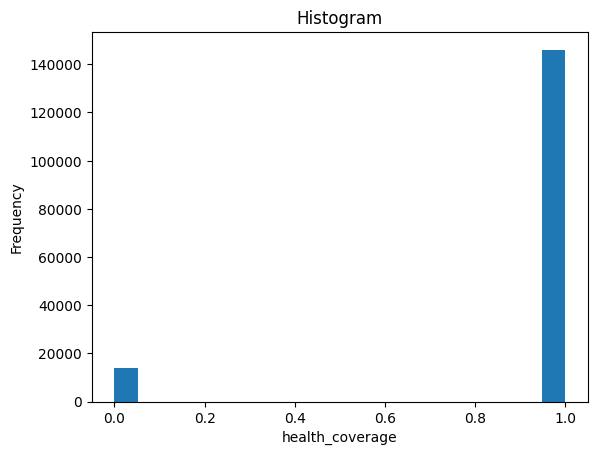

In [59]:
all_merged_data['health_coverage'] = np.where(
    (all_merged_data['insured'] == 0) | (all_merged_data['insurance_accepted'] == 0), 0, 
    np.where((all_merged_data['insured'] == 1) | (all_merged_data['insurance_accepted'] == 1), 1,
             np.nan)
)

columns=['insured', 'insurance_accepted']

# Subset the DataFrame to include only the specified columns
df_subset = all_merged_data[columns]

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

# Plot histogram
plt.hist(all_merged_data['health_coverage'], bins='auto')
plt.xlabel('health_coverage')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

all_merged_data.drop(['insured', 'insurance_accepted'], axis=1, inplace=True)

In [60]:
# Pivot 'demo_long_df' to wide format with 'person_id' as the index, 'question_concept_id' as the columns, and 'answer_concept_id' as the values, assigning the result to 'demo_wide'
demo_wide = hcau.pivot(index='person_id', columns='question', values='answer')

In [61]:
hcau_health_advice = demo_wide.loc[:, demo_wide.columns.str.contains('Health Advice:', na=False)]


/tmp/ipykernel_105/2133173662.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice['Health Advice: Eye Doctor Visits'] = np.where(
/tmp/ipykernel_105/2133173662.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice.drop(columns=['Health Advice: Spoken To Eye Doctor'], inplace=True)
/tmp/ipykernel_105/2133173662.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

<Axes: >

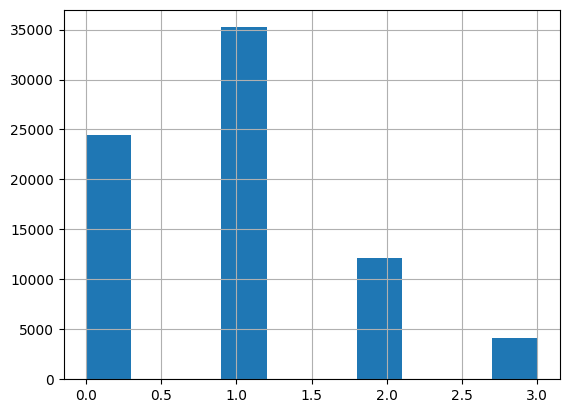

In [62]:
# Replace 'Health Advice: Eye Doctor Visits' based on 'Health Advice: Spoken To Eye Doctor'
hcau_health_advice['Health Advice: Eye Doctor Visits'] = np.where(
    hcau_health_advice['Health Advice: Spoken To Eye Doctor'] == 'Spoken To Eye Doctor: Yes',
    hcau_health_advice['Health Advice: Eye Doctor Visits'],
    hcau_health_advice['Health Advice: Spoken To Eye Doctor']
)

# Drop 'Health Advice: Spoken To Eye Doctor'
hcau_health_advice.drop(columns=['Health Advice: Spoken To Eye Doctor'], inplace=True)

# Extract numerical values from 'Health Advice: Eye Doctor Visits'
hcau_health_advice['Health Advice: Eye Doctor Visits'] = hcau_health_advice['Health Advice: Eye Doctor Visits'].str.split(':', n=1).str[1]

# Recode values in 'Health Advice: Eye Doctor Visits'

hcau_health_advice['Eye Doctor Visits'] = hcau_health_advice['Health Advice: Eye Doctor Visits'].replace({" 16 or More": 3,
    " 13 to 15": 3,
    " 10 to 12": 3,
    " 8 to 9": 3,
    " 6 to 7": 3,
    " 4 to 5": 3,
    " 2 to 3": 2,
    " 1": 1,
    " No": 0, 
    " Skip": np.nan, 
    " Dont Know": np.nan}).astype(float)

hcau_health_advice.drop(columns=['Health Advice: Eye Doctor Visits'], inplace=True)

# Plot histogram
hcau_health_advice['Eye Doctor Visits'].hist()


/tmp/ipykernel_105/186184276.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice['Health Advice: Nurse Practitioner, Physician Assistant, or Midwife Visits'] = np.where(
/tmp/ipykernel_105/186184276.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice.drop(columns=['Health Advice: Spoken To Nurse Practitioner'], inplace=True)
/tmp/ipykernel_105/186184276.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

<Axes: >

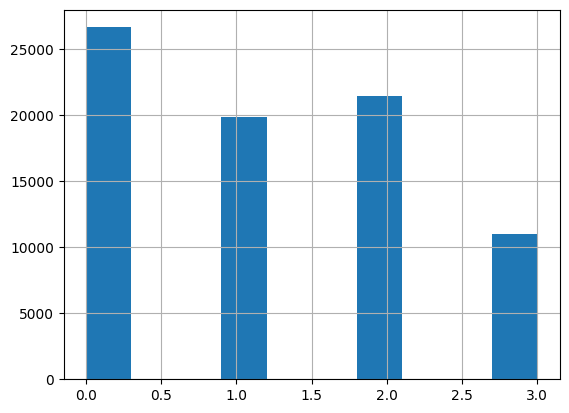

In [63]:
# Replace 'Health Advice: Nurse Practitioner Visits' based on 'Health Advice: Spoken To Nurse Practitioner'
hcau_health_advice['Health Advice: Nurse Practitioner, Physician Assistant, or Midwife Visits'] = np.where(
    hcau_health_advice['Health Advice: Spoken To Nurse Practitioner'] == 'Spoken To Nurse Practitioner: Yes',
    hcau_health_advice['Health Advice: Nurse Practitioner, Physician Assistant, or Midwife Visits'],
    hcau_health_advice['Health Advice: Spoken To Nurse Practitioner']
)

# Drop 'Health Advice: Spoken To Nurse Practitioner'
hcau_health_advice.drop(columns=['Health Advice: Spoken To Nurse Practitioner'], inplace=True)

# Extract numerical values from 'Health Advice: Nurse Practitioner Visits'
hcau_health_advice['Health Advice: Nurse Practitioner, Physician Assistant, or Midwife Visits'] = hcau_health_advice['Health Advice: Nurse Practitioner, Physician Assistant, or Midwife Visits'].str.split(':', n=1).str[1]

# Recode values in 'Health Advice: Nurse Practitioner Visits'

hcau_health_advice['Nurse Practitioner Visits'] = hcau_health_advice['Health Advice: Nurse Practitioner, Physician Assistant, or Midwife Visits'].replace({" 16 or More": 3,
    " 13 to 15": 3,
    " 10 to 12": 3,
    " 8 to 9": 3,
    " 6 to 7": 3,
    " 4 to 5": 3,
    " 2 to 3": 2,
    " 1": 1,
    " No": 0, 
    " Skip": np.nan, 
    " Dont Know": np.nan}).astype(float)

hcau_health_advice.drop(columns=['Health Advice: Nurse Practitioner, Physician Assistant, or Midwife Visits'], inplace=True)

# Plot histogram
hcau_health_advice['Nurse Practitioner Visits'].hist()


/tmp/ipykernel_105/3498629405.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice['Health Advice: Medical Specialist Visits'] = np.where(
/tmp/ipykernel_105/3498629405.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice.drop(columns=['Health Advice: Spoken To Medical Specialist'], inplace=True)
/tmp/ipykernel_105/3498629405.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

<Axes: >

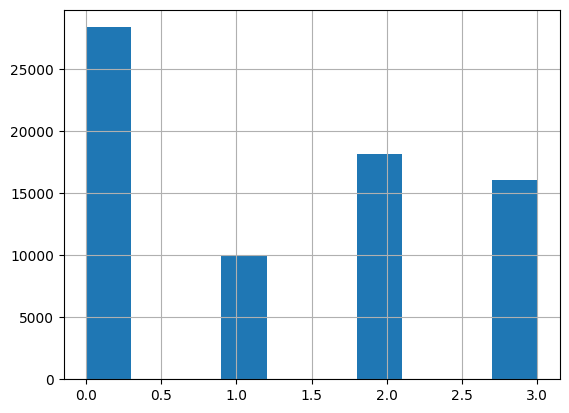

In [64]:
# Replace 'Health Advice: Medical Specialist Visits' based on 'Health Advice: Spoken To Medical Specialist'
hcau_health_advice['Health Advice: Medical Specialist Visits'] = np.where(
    hcau_health_advice['Health Advice: Spoken To Medical Specialist'] == 'Spoken To Medical Specialist: Yes',
    hcau_health_advice['Health Advice: Medical Specialist Visits'],
    hcau_health_advice['Health Advice: Spoken To Medical Specialist']
)

# Drop 'Health Advice: Spoken To Medical Specialist'
hcau_health_advice.drop(columns=['Health Advice: Spoken To Medical Specialist'], inplace=True)

# Extract numerical values from 'Health Advice: Medical Specialist Visits'
hcau_health_advice['Health Advice: Medical Specialist Visits'] = hcau_health_advice['Health Advice: Medical Specialist Visits'].str.split(':', n=1).str[1]

# Recode values in 'Health Advice: Medical Specialist Visits'

hcau_health_advice['Medical Specialist Visits'] = hcau_health_advice['Health Advice: Medical Specialist Visits'].replace({" 16 or More": 3,
    " 13 to 15": 3,
    " 10 to 12": 3,
    " 8 to 9": 3,
    " 6 to 7": 3,
    " 4 to 5": 3,
    " 2 to 3": 2,
    " 1": 1,
    " No": 0, 
    " Skip": np.nan, 
    " Dont Know": np.nan}).astype(float)

hcau_health_advice.drop(columns=['Health Advice: Medical Specialist Visits'], inplace=True)


# Plot histogram
hcau_health_advice['Medical Specialist Visits'].hist()


/tmp/ipykernel_105/1995639374.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice['Health Advice: Dentist or Orthodontist Visits'] = np.where(
/tmp/ipykernel_105/1995639374.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice.drop(columns=['Health Advice: Spoken To Dentist or Orthodontist'], inplace=True)
/tmp/ipykernel_105/1995639374.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

<Axes: >

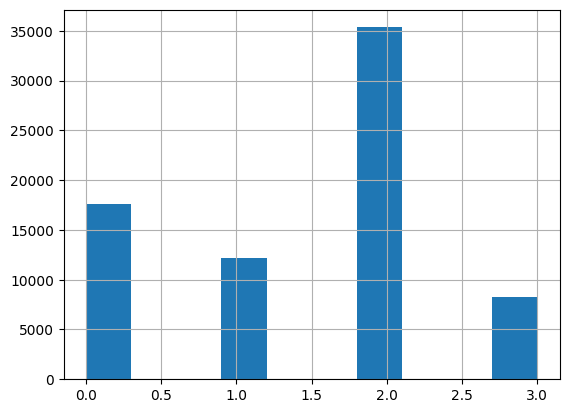

In [65]:
# Replace 'Health Advice: Dentist or Orthodontist Visits' based on 'Health Advice: Spoken To Dentist or Orthodontist'
hcau_health_advice['Health Advice: Dentist or Orthodontist Visits'] = np.where(
    hcau_health_advice['Health Advice: Spoken To Dentist or Orthodontist'] == 'Spoken To Dentist or Orthodontist: Yes',
    hcau_health_advice['Health Advice: Dentist or Orthodontist Visits'],
    hcau_health_advice['Health Advice: Spoken To Dentist or Orthodontist']
)

# Drop 'Health Advice: Spoken To Dentist or Orthodontist'
hcau_health_advice.drop(columns=['Health Advice: Spoken To Dentist or Orthodontist'], inplace=True)

# Extract numerical values from 'Health Advice: Dentist or Orthodontist Visits'
hcau_health_advice['Health Advice: Dentist or Orthodontist Visits'] = hcau_health_advice['Health Advice: Dentist or Orthodontist Visits'].str.split(':', n=1).str[1]

# Recode values in 'Health Advice: Dentist or Orthodontist Visits'

hcau_health_advice['Dentist or Orthodontist Visits'] = hcau_health_advice['Health Advice: Dentist or Orthodontist Visits'].replace({" 16 or More": 3,
    " 13 to 15": 3,
    " 10 to 12": 3,
    " 8 to 9": 3,
    " 6 to 7": 3,
    " 4 to 5": 3,
    " 2 to 3": 2,
    " 1": 1,
    " No": 0, 
    " Skip": np.nan, 
    " Dont Know": np.nan}).astype(float)

hcau_health_advice.drop(columns=['Health Advice: Dentist or Orthodontist Visits'], inplace=True)


# Plot histogram
hcau_health_advice['Dentist or Orthodontist Visits'].hist()


/tmp/ipykernel_105/1062710187.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice['Health Advice: Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist Visits'] = np.where(
/tmp/ipykernel_105/1062710187.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice.drop(columns=['Health Advice: Spoken To Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist'], inplace=True)
/tmp/ipykernel_105/1062710187.py:12: SettingWithCopyWarning: 
A value is 

<Axes: >

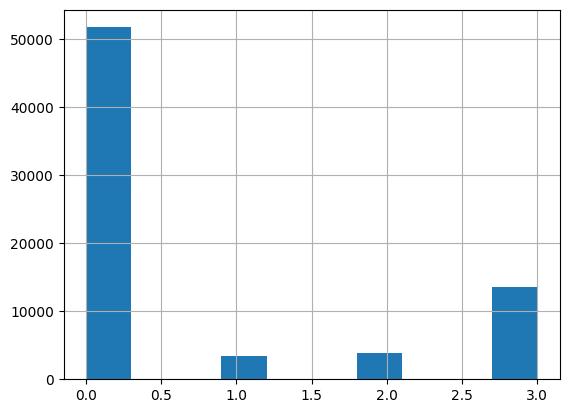

In [66]:
# Replace 'Health Advice: Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist Visits' based on 'Health Advice: Spoken To Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist'
hcau_health_advice['Health Advice: Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist Visits'] = np.where(
    hcau_health_advice['Health Advice: Spoken To Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist'] == 'Spoken To PT, ST, RT, Audiologist or OT: Yes',
    hcau_health_advice['Health Advice: Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist Visits'],
    hcau_health_advice['Health Advice: Spoken To Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist']
)

# Drop 'Health Advice: Spoken To Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist'
hcau_health_advice.drop(columns=['Health Advice: Spoken To Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist'], inplace=True)

# Extract numerical values from 'Health Advice: Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist Visits'
hcau_health_advice['Health Advice: Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist Visits'] = hcau_health_advice['Health Advice: Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist Visits'].str.split(':', n=1).str[1]

# Recode values in 'Health Advice: Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist Visits'

hcau_health_advice['Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist Visits'] = hcau_health_advice['Health Advice: Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist Visits'].replace({" 16 or More": 3,
    " 13 to 15": 3,
    " 10 to 12": 3,
    " 8 to 9": 3,
    " 6 to 7": 3,
    " 4 to 5": 3,
    " 2 to 3": 2,
    " 1": 1,
    " No": 0, 
    " Skip": np.nan, 
    " Dont Know": np.nan}).astype(float)

hcau_health_advice.drop(columns=['Health Advice: Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist Visits'], inplace=True)

# Plot histogram
hcau_health_advice['Physical Therapist, Speech Therapist, Respiratory Therapist, Audiologist, or Occupational Therapist Visits'].hist()


/tmp/ipykernel_105/2688372693.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice['Health Advice: Chiropractor Visits'] = np.where(
/tmp/ipykernel_105/2688372693.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice.drop(columns=['Health Advice: Spoken To Chiropractor'], inplace=True)
/tmp/ipykernel_105/2688372693.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o

<Axes: >

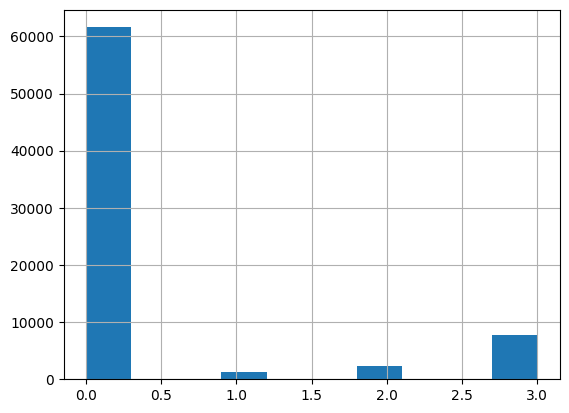

In [67]:
# Replace 'Health Advice: Chiropractor Visits' based on 'Health Advice: Spoken To Chiropractor'
hcau_health_advice['Health Advice: Chiropractor Visits'] = np.where(
    hcau_health_advice['Health Advice: Spoken To Chiropractor'] == 'Spoken To Chiropractor: Yes',
    hcau_health_advice['Health Advice: Chiropractor Visits'],
    hcau_health_advice['Health Advice: Spoken To Chiropractor']
)

# Drop 'Health Advice: Spoken To Chiropractor'
hcau_health_advice.drop(columns=['Health Advice: Spoken To Chiropractor'], inplace=True)

# Extract numerical values from 'Health Advice: Chiropractor Visits'
hcau_health_advice['Health Advice: Chiropractor Visits'] = hcau_health_advice['Health Advice: Chiropractor Visits'].str.split(':', n=1).str[1]

# Recode values in 'Health Advice: Chiropractor Visits'

hcau_health_advice['Chiropractor Visits'] = hcau_health_advice['Health Advice: Chiropractor Visits'].replace({" 16 or M ore": 3,
    " 13 to 15": 3,
    " 10 to 12": 3,
    " 8 to 9": 3,
    " 6 to 7": 3,
    " 4 to 5": 3,
    " 2 to 3": 2,
    " 1": 1,
    " No": 0, 
    " Skip": np.nan, 
    " Dont Know": np.nan}).astype(float)

hcau_health_advice.drop(columns=['Health Advice: Chiropractor Visits'], inplace=True)

# Plot histogram
hcau_health_advice['Chiropractor Visits'].hist()


/tmp/ipykernel_105/3650153418.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice['Health Advice: General Doctor Visits'] = np.where(
/tmp/ipykernel_105/3650153418.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice.drop(columns=['Health Advice: Spoken To General Doctor'], inplace=True)
/tmp/ipykernel_105/3650153418.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

<Axes: >

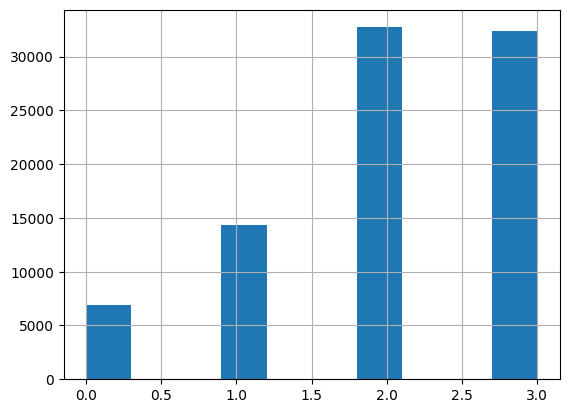

In [68]:
# Replace 'Health Advice: General Doctor Visits' based on 'Health Advice: Spoken To General Doctor'
hcau_health_advice['Health Advice: General Doctor Visits'] = np.where(
    hcau_health_advice['Health Advice: Spoken To General Doctor'] == 'Spoken To General Doctor: Yes',
    hcau_health_advice['Health Advice: General Doctor Visits'],
    hcau_health_advice['Health Advice: Spoken To General Doctor']
)

# Drop 'Health Advice: Spoken To General Doctor'
hcau_health_advice.drop(columns=['Health Advice: Spoken To General Doctor'], inplace=True)

# Extract numerical values from 'Health Advice: General Doctor Visits'
hcau_health_advice['Health Advice: General Doctor Visits'] = hcau_health_advice['Health Advice: General Doctor Visits'].str.split(':', n=1).str[1]

# Recode values in 'Health Advice: General Doctor Visits'

hcau_health_advice['General Doctor Visits'] = hcau_health_advice['Health Advice: General Doctor Visits'].replace({" 16 or M ore": 3,
    " 13 to 15": 3,
    " 10 to 12": 3,
    " 8 to 9": 3,
    " 6 to 7": 3,
    " 4 to 5": 3,
    " 2 to 3": 2,
    " 1": 1,
    " No": 0, 
    " Skip": np.nan, 
    " Dont Know": np.nan}).astype(float)


hcau_health_advice.drop(columns=['Health Advice: General Doctor Visits'], inplace=True)


# Plot histogram
hcau_health_advice['General Doctor Visits'].hist()


/tmp/ipykernel_105/1022680213.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice['Health Advice: Podiatrist Visits'] = np.where(
/tmp/ipykernel_105/1022680213.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice.drop(columns=['Health Advice: Spoken To Podiatrist'], inplace=True)
/tmp/ipykernel_105/1022680213.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

<Axes: >

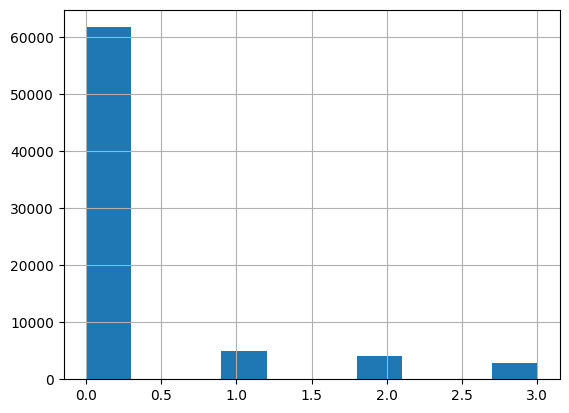

In [69]:
# Replace 'Health Advice: Podiatrist Visits' based on 'Health Advice: Spoken To Podiatrist'
hcau_health_advice['Health Advice: Podiatrist Visits'] = np.where(
    hcau_health_advice['Health Advice: Spoken To Podiatrist'] == 'Spoken To Podiatrist: Yes',
    hcau_health_advice['Health Advice: Podiatrist Visits'],
    hcau_health_advice['Health Advice: Spoken To Podiatrist']
)

# Drop 'Health Advice: Spoken To Podiatrist'
hcau_health_advice.drop(columns=['Health Advice: Spoken To Podiatrist'], inplace=True)

# Extract numerical values from 'Health Advice: Podiatrist Visits'
hcau_health_advice['Health Advice: Podiatrist Visits'] = hcau_health_advice['Health Advice: Podiatrist Visits'].str.split(':', n=1).str[1]

# Recode values in 'Health Advice: Podiatrist Visits'

hcau_health_advice['Podiatrist Visits'] = hcau_health_advice['Health Advice: Podiatrist Visits'].replace({" 16 or More": 3,
    " 13 to 15": 3,
    " 10 to 12": 3,
    " 8 to 9": 3,
    " 6 to 7": 3,
    " 4 to 5": 3,
    " 2 to 3": 2,
    " 1": 1,
    " No": 0, 
    " Skip": np.nan, 
    " Dont Know": np.nan}).astype(float)

hcau_health_advice.drop(columns=['Health Advice: Podiatrist Visits'], inplace=True)


# Plot histogram
hcau_health_advice['Podiatrist Visits'].hist()


/tmp/ipykernel_105/1120244043.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice['Health Advice: Mental Health Professional Visits'] = np.where(
/tmp/ipykernel_105/1120244043.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice.drop(columns=['Health Advice: Spoken To Mental Health Professional'], inplace=True)
/tmp/ipykernel_105/1120244043.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentat

<Axes: >

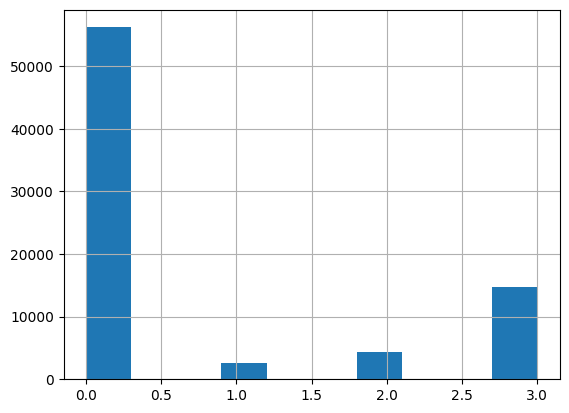

In [70]:
# Replace 'Health Advice: Mental Health Professional Visits' based on 'Health Advice: Spoken To Mental Health Professional'
hcau_health_advice['Health Advice: Mental Health Professional Visits'] = np.where(
    hcau_health_advice['Health Advice: Spoken To Mental Health Professional'] == 'Spoken To Mental Health Professional: Yes',
    hcau_health_advice['Health Advice: Mental Health Professional Visits'],
    hcau_health_advice['Health Advice: Spoken To Mental Health Professional']
)

# Drop 'Health Advice: Spoken To Mental Health Professional'
hcau_health_advice.drop(columns=['Health Advice: Spoken To Mental Health Professional'], inplace=True)

# Extract numerical values from 'Health Advice: Mental Health Professional Visits'
hcau_health_advice['Health Advice: Mental Health Professional Visits'] = hcau_health_advice['Health Advice: Mental Health Professional Visits'].str.split(':', n=1).str[1]

# Recode values in 'Health Advice: Mental Health Professional Visits'

hcau_health_advice['Mental Health Professional Visits'] = hcau_health_advice['Health Advice: Mental Health Professional Visits'].replace({" 16 or More": 3,
    " 13 to 15": 3,
    " 10 to 12": 3,
    " 8 to 9": 3,
    " 6 to 7": 3,
    " 4 to 5": 3,
    " 2 to 3": 2,
    " 1": 1,
    " No": 0, 
    " Skip": np.nan, 
    " Dont Know": np.nan}).astype(float)

hcau_health_advice.drop(columns=['Health Advice: Mental Health Professional Visits'], inplace=True)



# Plot histogram
hcau_health_advice['Mental Health Professional Visits'].hist()


/tmp/ipykernel_105/206151041.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice['Health Advice: Traditional Healer Visits'] = np.where(
/tmp/ipykernel_105/206151041.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice.drop(columns=['Health Advice: Spoken To Traditional Healer'], inplace=True)
/tmp/ipykernel_105/206151041.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas

<Axes: >

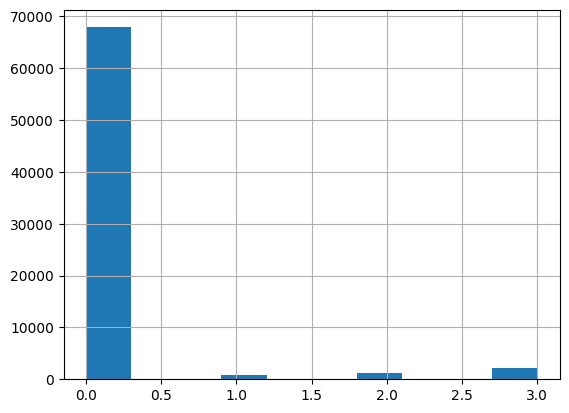

In [71]:
# Replace 'Health Advice: Traditional Healer Visits' based on 'Health Advice: Spoken To Traditional Healer'
hcau_health_advice['Health Advice: Traditional Healer Visits'] = np.where(
    hcau_health_advice['Health Advice: Spoken To Traditional Healer'] == 'Spoken To Traditional Healer: Yes',
    hcau_health_advice['Health Advice: Traditional Healer Visits'],
    hcau_health_advice['Health Advice: Spoken To Traditional Healer']
)

# Drop 'Health Advice: Spoken To Traditional Healer'
hcau_health_advice.drop(columns=['Health Advice: Spoken To Traditional Healer'], inplace=True)

# Extract numerical values from 'Health Advice: Traditional Healer Visits'
hcau_health_advice['Health Advice: Traditional Healer Visits'] = hcau_health_advice['Health Advice: Traditional Healer Visits'].str.split(':', n=1).str[1]

# Recode values in 'Health Advice: Traditional Healer Visits'

hcau_health_advice['Traditional Healer Visits'] = hcau_health_advice['Health Advice: Traditional Healer Visits'].replace({" 16 or More": 3,
    " 13 to 15": 3,
    " 10 to 12": 3,
    " 8 to 9": 3,
    " 6 to 7": 3,
    " 4 to 5": 3,
    " 2 to 3": 2,
    " 1": 1,
    " No": 0, 
    " Skip": np.nan, 
    " Dont Know": np.nan}).astype(float)

hcau_health_advice.drop(columns=['Health Advice: Traditional Healer Visits'], inplace=True)



# Plot histogram
hcau_health_advice['Traditional Healer Visits'].hist()


/tmp/ipykernel_105/7646873.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice['Health Advice: OB/GYN Visits'] = np.where(
/tmp/ipykernel_105/7646873.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcau_health_advice.drop(columns=['Health Advice: Spoken To OB/GYN'], inplace=True)
/tmp/ipykernel_105/7646873.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

<Axes: >

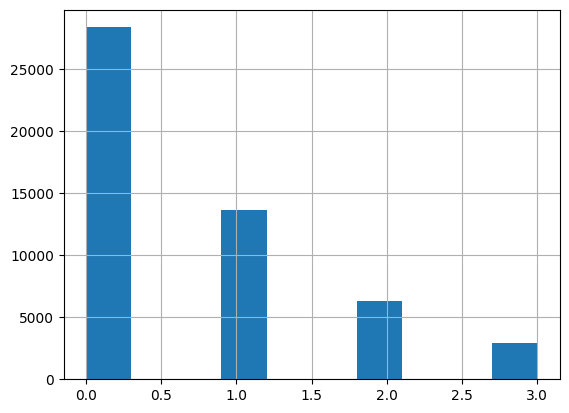

In [72]:
# Replace 'Health Advice: OB/GYN Visits' based on 'Health Advice: Spoken To OB/GYN'
hcau_health_advice['Health Advice: OB/GYN Visits'] = np.where(
    hcau_health_advice['Health Advice: Spoken To OB/GYN'] == 'Spoken To OB/GYN: Yes',
    hcau_health_advice['Health Advice: OB/GYN Visits'],
    hcau_health_advice['Health Advice: Spoken To OB/GYN']
)

# Drop 'Health Advice: Spoken To OB/GYN'
hcau_health_advice.drop(columns=['Health Advice: Spoken To OB/GYN'], inplace=True)

# Extract numerical values from 'Health Advice: OB/GYN Visits'
hcau_health_advice['Health Advice: OB/GYN Visits'] = hcau_health_advice['Health Advice: OB/GYN Visits'].str.split(':', n=1).str[1]

# Recode values in 'Health Advice: OB/GYN Visits'

hcau_health_advice['OB/GYN Visits'] = hcau_health_advice['Health Advice: OB/GYN Visits'].replace({" 16 or More": 3,
    " 13 to 15": 3,
    " 10 to 12": 3,
    " 8 to 9": 3,
    " 6 to 7": 3,
    " 4 to 5": 3,
    " 2 to 3": 2,
    " 1": 1,
    " No": 0, 
    " Skip": np.nan, 
    " Dont Know": np.nan}).astype(float)

hcau_health_advice.drop(columns=['Health Advice: OB/GYN Visits'], inplace=True)


# Plot histogram
hcau_health_advice['OB/GYN Visits'].hist()


In [73]:
hcau_health_advice=hcau_health_advice.drop(hcau_health_advice.columns[:6], axis=1)
# Remove rows with more than 4 NaN values
hcau_health_advice = hcau_health_advice.dropna(thresh=hcau_health_advice.shape[1] - 4)


Cronbach's alpha: 0.56
[0.551 0.561]


<Axes: >

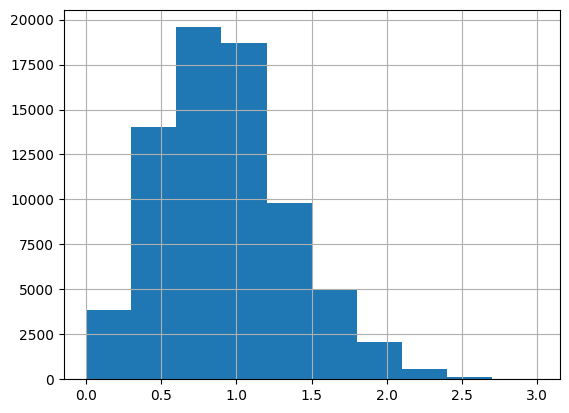

In [74]:
# Subset the DataFrame to include only the specified columns
df_subset = hcau_health_advice

# Remove rows with NaN or infinite values
df_subset_clean = df_subset.replace([np.inf, -np.inf], np.nan).dropna()

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

hcau_health_advice['health_care_use'] = hcau_health_advice.mean(axis=1, skipna=True)


all_merged_data = pd.merge(all_merged_data, hcau_health_advice['health_care_use'], on='person_id', how='left')

all_merged_data['health_care_use'].hist()


In [75]:
# Calculate item-total correlations manually
from scipy.stats import pearsonr
item_total_corr = {}

# For each item, calculate correlation with the total score
for col in df_subset_clean.columns:
    total_score = df_subset_clean.drop(columns=[col]).sum(axis=1)
    corr, _ = pearsonr(df_subset_clean[col], total_score)
    item_total_corr[col] = corr

# Convert to DataFrame
item_total_corr_df = pd.DataFrame(list(item_total_corr.items()), columns=['Item', 'Item-Total Correlation'])

# Display item-total correlations for evaluation
print(item_total_corr_df)

# Identify items with item-total correlation less than 0.15
low_corr_items = item_total_corr_df[item_total_corr_df['Item-Total Correlation'] < 0.29]['Item']
print(low_corr_items)

# Remove items with low item-total correlations from the dataframe
df_filtered = df_subset_clean.drop(columns=low_corr_items)

# Recalculate Cronbach's alpha after removing low-correlation items
cronbach_alpha_filtered = pg.cronbach_alpha(data=df_filtered)

# Extract raw Cronbach's alpha and confidence intervals
raw_alpha_filtered = cronbach_alpha_filtered[0]
conf_int_filtered = cronbach_alpha_filtered[1]

print(f"New Cronbach's Alpha: {raw_alpha_filtered}")
print(f"Confidence Interval: {conf_int_filtered}")

                                                 Item  Item-Total Correlation
0                                   Eye Doctor Visits                0.211984
1                           Nurse Practitioner Visits                0.324668
2                           Medical Specialist Visits                0.366381
3                      Dentist or Orthodontist Visits                0.139419
4   Physical Therapist, Speech Therapist, Respirat...                0.303015
5                                 Chiropractor Visits                0.139209
6                               General Doctor Visits                0.292033
7                                   Podiatrist Visits                0.170435
8                   Mental Health Professional Visits                0.216837
9                           Traditional Healer Visits                0.172196
10                                      OB/GYN Visits                0.142039
0                     Eye Doctor Visits
3        Dentist or Orth

In [76]:
hcau[['question_concept_id', 'question']].drop_duplicates()

,question_concept_id,question
0,<NA>,NaN
5,43529973,"Health Advice: Nurse Practitioner, Physician A..."
6,43530413,Can't Afford Care: Lower Cost Rx To Save Money
7,43529974,Health Advice: Dentist or Orthodontist Visits
8,43528666,Can't Afford Care: Alternative Therapies
9,43530437,Health Advice: Asked For Opinion
10,43528665,Can't Afford Care: Bought Rx From Other Country
11,43528663,Can't Afford Care: Emergency Care
12,43528662,Can't Afford Care: Dental Care
13,43530408,Can't Afford Care: Eyeglasses


In [77]:
delayed_care = demo_wide.loc[:, demo_wide.columns.str.contains('Delayed Medical Care:', na=False)]
delayed_care = delayed_care.apply(lambda col: col.str.split(':', n=1).str[1])

replacement_dict = {
    " Yes": 1,
    " No": 0,
    " Skip": np.nan,
    " Dont Know": np.nan
}

# Apply the replacement to all columns
delayed_care = delayed_care.applymap(lambda x: replacement_dict.get(x, x))

# Convert to float
delayed_care = delayed_care.astype(float)

# Remove rows with more than 2 NaN values
delayed_care = delayed_care.dropna(thresh=delayed_care.shape[1] - 2)

# Subset the DataFrame to include only the specified columns
df_subset = delayed_care

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

delayed_care['delayed_care'] = delayed_care.apply(lambda row: 0 if not (row == 1).any() else 1, axis=1)

delayed_care = delayed_care['delayed_care']

Cronbach's alpha: 0.63
[0.629 0.637]


In [78]:
# Remove rows with NaN or infinite values
df_subset_clean = df_subset.replace([np.inf, -np.inf], np.nan).dropna()

# Calculate item-total correlations manually
from scipy.stats import pearsonr
item_total_corr = {}

# For each item, calculate correlation with the total score
for col in df_subset_clean.columns:
    total_score = df_subset_clean.drop(columns=[col]).sum(axis=1)
    corr, _ = pearsonr(df_subset_clean[col], total_score)
    item_total_corr[col] = corr

# Convert to DataFrame
item_total_corr_df = pd.DataFrame(list(item_total_corr.items()), columns=['Item', 'Item-Total Correlation'])

# Display item-total correlations for evaluation
print(item_total_corr_df)

# Identify items with item-total correlation less than 0.15
low_corr_items = item_total_corr_df[item_total_corr_df['Item-Total Correlation'] < 0.30]['Item']
print(low_corr_items)

# Remove items with low item-total correlations from the dataframe
df_filtered = df_subset_clean.drop(columns=low_corr_items)

# Recalculate Cronbach's alpha after removing low-correlation items
cronbach_alpha_filtered = pg.cronbach_alpha(data=df_filtered)

# Extract raw Cronbach's alpha and confidence intervals
raw_alpha_filtered = cronbach_alpha_filtered[0]
conf_int_filtered = cronbach_alpha_filtered[1]

print(f"New Cronbach's Alpha: {raw_alpha_filtered}")
print(f"Confidence Interval: {conf_int_filtered}")

                                             Item  Item-Total Correlation
0       Delayed Medical Care: Can't Afford Co-pay                0.495741
1                Delayed Medical Care: Child Care                0.210954
2       Delayed Medical Care: Deductible Too High                0.513204
3              Delayed Medical Care: Elderly Care                0.160770
4  Delayed Medical Care: Had To Pay Out Of Pocket                0.529822
5                   Delayed Medical Care: Nervous                0.349273
6                Delayed Medical Care: Rural Area                0.224243
7             Delayed Medical Care: Time Off Work                0.344032
8            Delayed Medical Care: Transportation                0.299630
9                                    delayed_care                0.786235
1        Delayed Medical Care: Child Care
3      Delayed Medical Care: Elderly Care
6        Delayed Medical Care: Rural Area
8    Delayed Medical Care: Transportation
Name: Item, dtype:

/tmp/ipykernel_105/3658797249.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delayed_care['delayed_care'] = df_filtered.apply(lambda row: 0 if not (row == 1).any() else 1, axis=1)


<Axes: >

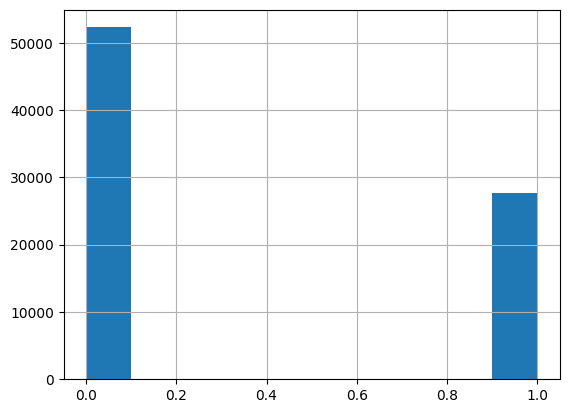

In [79]:
df_filtered = df_filtered.drop(columns="delayed_care")

delayed_care['delayed_care'] = df_filtered.apply(lambda row: 0 if not (row == 1).any() else 1, axis=1)

delayed_care = pd.Series(delayed_care, name='delayed_care')

all_merged_data = pd.merge(all_merged_data, delayed_care , on='person_id', how='left')

all_merged_data['delayed_care'].hist()

(162193, 14)
Cronbach's alpha: 0.85
[0.845 0.848]


<Axes: >

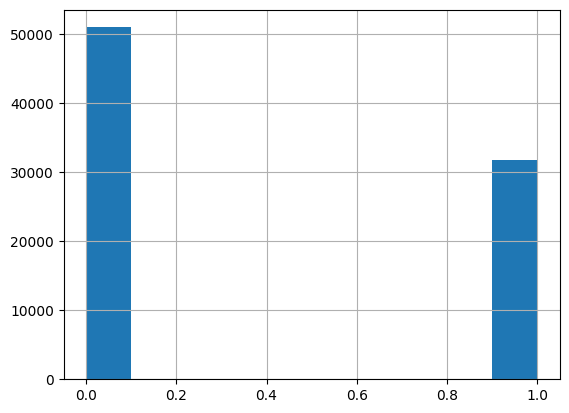

In [80]:
afford_care = demo_wide.loc[:, demo_wide.columns.str.contains('Afford Care:', na=False)]
afford_care = afford_care.apply(lambda col: col.str.split(':', n=1).str[1])
afford_care = afford_care.iloc[:, :-1]

replacement_dict = {
    " Yes": 1,
    " No": 0,
    " Skip": np.nan,
    " Dont Know": np.nan
}

# Apply the replacement to all columns
afford_care = afford_care.applymap(lambda x: replacement_dict.get(x, x))

print(afford_care.shape)

# Convert to float
afford_care = afford_care.astype(float)

# Remove rows with more than 2 NaN values
afford_care = afford_care.dropna(thresh=afford_care.shape[1] - 4)

# Subset the DataFrame to include only the specified columns
df_subset = afford_care

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

afford_care['afford_care'] = afford_care.apply(lambda row: 0 if not (row == 1).any() else 1, axis=1)

afford_care = afford_care['afford_care']

all_merged_data = pd.merge(all_merged_data, afford_care , on='person_id', how='left')

all_merged_data['afford_care'].hist()

<Axes: >

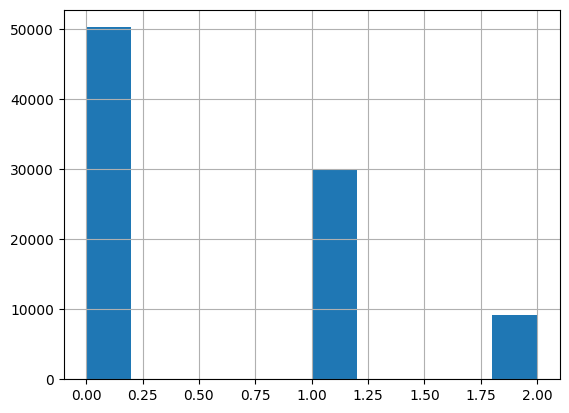

In [81]:
worried = demo_wide.loc[:, demo_wide.columns.str.contains('Worried', na=False)]
worried = worried.apply(lambda col: col.str.split(':', n=1).str[1])

replacement_dict = {
    " Not At All Worried": 0,
    " Somewhat Worried": 1,
    " Very Worried": 2,
    " Skip": np.nan,
    " Dont Know": np.nan
}

# Apply the replacement to all columns
worried = worried.applymap(lambda x: replacement_dict.get(x, x))

# Convert to float
worried = worried.astype(float)

#rename 
worried.columns.values[0] = 'worried_pay'

worried = worried['worried_pay']

all_merged_data = pd.merge(all_merged_data, worried, on='person_id', how='left')

all_merged_data['worried_pay'].hist()

(162193, 3)
Cronbach's alpha: 0.60
[0.596 0.605]


<Axes: >

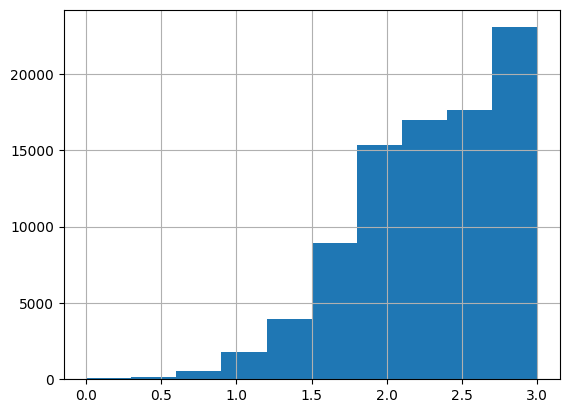

In [82]:
respect = demo_wide.loc[:, demo_wide.columns.str.contains('Health Advice', na=False)].iloc[:, [0, 3, 13]]
respect = respect.apply(lambda col: col.str.split(':', n=1).str[1])
respect

replacement_dict = {
    " None Of The Time": 0,
    " Some Of The Time": 1,
    " Most Of The Time": 2,
    " Always": 3,
    " Skip": np.nan,
    " Dont Know": np.nan,
}

#Apply the replacement to all columns
respect = respect.applymap(lambda x: replacement_dict.get(x, x))

print(respect.shape)

# Convert to float
respect = respect.astype(float)

# Remove rows with more than 1 NaN values
respect = respect.dropna(thresh=respect.shape[1] - 1)

# Subset the DataFrame to include only the specified columns
df_subset = respect

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=df_subset)

# Extract raw and standardized Cronbach's alpha
raw_alpha = cronbach_alpha[0]
conf_int = cronbach_alpha[1]

# Display the result
print(f"Cronbach's alpha: {raw_alpha:.2f}")
print(conf_int)

respect['respect'] = respect.mean(axis=1)

respect = respect['respect']

all_merged_data = pd.merge(all_merged_data, respect, on='person_id', how='left')

all_merged_data['respect'].hist()

# Make Poverty Score

In [83]:
os.system(f"gsutil cp 'gs://fc-secure-5e7b1abd-1cd7-485e-8567-bf3cb4814b5c/data/poverty-guidelines-48-states.csv' .")
pov_states = pd.read_csv('poverty-guidelines-48-states.csv')

os.system(f"gsutil cp 'gs://fc-secure-5e7b1abd-1cd7-485e-8567-bf3cb4814b5c/data/poverty-guidelines-hawaii.csv' .")
pov_hawaii = pd.read_csv('poverty-guidelines-hawaii.csv')

pov_states['Date of Publication'] = pd.to_datetime(pov_states['Date of Publication'], format='%B %Y')
pov_hawaii['Date of Publication'] = pd.to_datetime(pov_hawaii['Date of Publication'], format='%B %Y')

# Function to clean and convert columns to numeric
def clean_and_convert(df, columns):
    for col in columns:
        df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)
    return df

# Clean and convert numeric columns in pov_states and pov_hawaii
numeric_columns = ['1 Person', '2 Persons', '3 Persons', '4 Persons', '5 Persons', '6 Persons', '7 Persons', '8 Persons', '$ For Each Additional Person (9+)']
pov_states = clean_and_convert(pov_states, numeric_columns)
pov_hawaii = clean_and_convert(pov_hawaii, numeric_columns)

pov_states['Date of Publication'] = pov_states['Date of Publication'].dt.tz_localize(None)
pov_hawaii['Date of Publication'] = pov_hawaii['Date of Publication'].dt.tz_localize(None)

pov_hawaii.head(5)

Copying gs://fc-secure-5e7b1abd-1cd7-485e-8567-bf3cb4814b5c/data/poverty-guidelines-48-states.csv...
/ [1 files][ 13.6 KiB/ 13.6 KiB]                                                
Operation completed over 1 objects/13.6 KiB.                                     
Copying gs://fc-secure-5e7b1abd-1cd7-485e-8567-bf3cb4814b5c/data/poverty-guidelines-hawaii.csv...
/ [1 files][ 12.8 KiB/ 12.8 KiB]                                                
Operation completed over 1 objects/12.8 KiB.                                     


,Date of Publication,Year,1 Person,2 Persons,3 Persons,4 Persons,5 Persons,6 Persons,7 Persons,8 Persons,$ For Each Additional Person (9+),Unnamed: 11,Documentation,HTML Link
0,2024-01-01,2024,18810.0,25540.0,32270.0,39000.0,45730.0,52460.0,59190.0,65920.0,6730.0,NaN,"2024 Vol. 89, No. 11, January 17, 2024, pp. 29...",https://www.govinfo.gov/content/pkg/FR-2024-01...
1,2023-01-01,2023,18210.0,24640.0,31070.0,37500.0,43930.0,50360.0,56790.0,63220.0,6430.0,NaN,"2023 Vol. 88, No. 12, January 19, 2023, pp. 34...",https://www.govinfo.gov/content/pkg/FR-2023-01...
2,2022-01-01,2022,16990.0,22890.0,28790.0,34690.0,40590.0,46490.0,52390.0,58290.0,5900.0,NaN,"2022 Vol. 87, No. 14, January 21, 2022, pp. 33...",https://www.govinfo.gov/content/pkg/FR-2022-01...
3,2021-02-01,2021,16090.0,21770.0,27450.0,33130.0,38810.0,44490.0,50170.0,55850.0,5680.0,NaN,"2021 Vol. 86, No. 19, February 1, 2021, pp. 77...",https://www.govinfo.gov/content/pkg/FR-2021-02...
4,2020-01-01,2020,15950.0,21550.0,27150.0,32750.0,38350.0,43950.0,49550.0,55150.0,5600.0,NaN,"2020 Vol. 85, No. 12, January 17, 2020, pp. 30...",https://www.govinfo.gov/content/pkg/FR-2020-01...


In [84]:
# Function to assign location based on zip_code
def assign_location(zip_code):
    if zip_code.startswith('995'):
        return 'alaska'
    elif zip_code.startswith('967'):
        return 'hawaii'
    else:
        return 'states'

# Apply the function to create the location column
zip_code_socioeconomic_df['location'] = zip_code_socioeconomic_df['zip_code'].apply(assign_location)

# Create new DataFrame with person_id and location columns
demo_df = zip_code_socioeconomic_df[['person_id', 'location']]

#Add in number living
demo_df = pd.merge(demo_df, all_merged_data[['number_living', 'person_id']], on="person_id")

print(demo_df['location'].value_counts())


location
states    156728
hawaii        25
alaska         3
Name: count, dtype: int64


In [85]:
filtered_data = survey_df[survey_df['question_concept_id'] == 1585375]

# Remove duplicates and keep the first occurrence of each person_id
filtered_data = filtered_data.drop_duplicates(subset='person_id', keep='first')

filtered_data = filtered_data[['person_id', 'survey_datetime', 'answer']]


# Define the desired order of the answer categories

filtered_data['answer'] = filtered_data['answer'].apply(lambda x: 'skip' if 'PMI:' in x else x)

# Convert 'answer' column to categorical data with defined order
filtered_data['answer'] = pd.Categorical(filtered_data['answer'])

filtered_data['answer'] = filtered_data['answer'].replace({'Annual Income: less 10k': 5000,
                                                'Annual Income: 10k 25k': 12500,
                                                'Annual Income: 25k 35k': 30000,
                                                'Annual Income: 35k 50k': 42500,
                                                'Annual Income: 50k 75k': 62500,
                                                'Annual Income: 75k 100k': 87500,
                                                'Annual Income: 100k 150k': 125000,
                                                'Annual Income: 150k 200k': 175000,
                                                'Annual Income: more 200k': 225000,
                                                               'skip':np.nan})

demo_df = pd.merge(demo_df, filtered_data, on="person_id")

demo_df['survey_datetime'] = pd.to_datetime(demo_df['survey_datetime'], format='%B %Y')

demo_df['survey_year_month'] = demo_df['survey_datetime'].dt.to_period('M').dt.to_timestamp()

demo_df['survey_datetime'] = demo_df['survey_datetime'].dt.tz_localize(None)


/tmp/ipykernel_105/3776232882.py:31: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  demo_df['survey_year_month'] = demo_df['survey_datetime'].dt.to_period('M').dt.to_timestamp()


In [86]:
# Function to find the closest date in pov_df and calculate the distance in months
def find_closest_date_and_distance(demo_date, pov_df):
    pov_df['date_diff'] = (pov_df['Date of Publication'] - demo_date).abs()
    closest_row = pov_df.loc[pov_df['date_diff'].idxmin()]
    distance_in_months = (closest_row['Date of Publication'].year - demo_date.year) * 12 + (closest_row['Date of Publication'].month - demo_date.month)
    distance_in_months = abs(distance_in_months)
    return closest_row, distance_in_months

# Function to merge demo_df with the closest date in pov_df and calculate the poverty threshold
def merge_and_calculate_threshold(demo, pov):
    merged_rows = []
    for _, demo_row in demo.iterrows():
        closest_pov_row, distance_in_months = find_closest_date_and_distance(demo_row['survey_datetime'], pov)
        merged_row = pd.concat([demo_row, closest_pov_row])
        merged_row['distance_in_months'] = distance_in_months
        merged_rows.append(merged_row)
    merged_df = pd.DataFrame(merged_rows)
    
    # Calculate poverty threshold
    def get_poverty_threshold(row):
        if row['number_living'] == 1:
            return row['1 Person']
        elif row['number_living'] == 2:
            return row['2 Persons']
        elif row['number_living'] == 3:
            return row['3 Persons']
        elif row['number_living'] == 4:
            return row['4 Persons']
        elif row['number_living'] == 5:
            return row['5 Persons']
        elif row['number_living'] == 6:
            return row['6 Persons']
        elif row['number_living'] == 7:
            return row['7 Persons']
        elif row['number_living'] == 8:
            return row['8 Persons']
        else:
            return row['8 Persons'] + (row['number_living'] - 8) * row['$ For Each Additional Person (9+)']
    
    merged_df['poverty_threshold'] = merged_df.apply(get_poverty_threshold, axis=1)
    return merged_df

# Separate demo_df into states and hawaii DataFrames
demo_states = demo_df[demo_df['location'] == 'states']
demo_hawaii = demo_df[demo_df['location'] == 'hawaii']

# Merge with the respective poverty data
print(demo_states.shape[0])
merged_states = merge_and_calculate_threshold(demo_states, pov_states)
print(merged_states.shape[0])

print(demo_hawaii.shape[0])
merged_hawaii = merge_and_calculate_threshold(demo_hawaii, pov_hawaii)
print(merged_hawaii.shape[0])

# Combine the two DataFrames
final_df = pd.concat([merged_states, merged_hawaii])

# Select the relevant columns to form the final DataFrame
final_df = final_df[['person_id', 'location', 'number_living', 'survey_datetime', 'answer', 'poverty_threshold', 'distance_in_months']]



156728
156728
25
25


<Axes: >

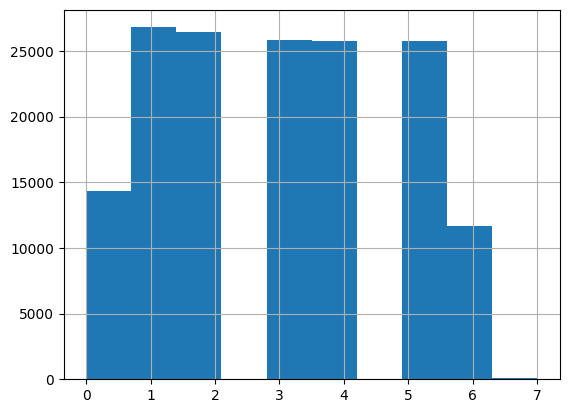

In [87]:
final_df['distance_in_months'].hist()

<Axes: >

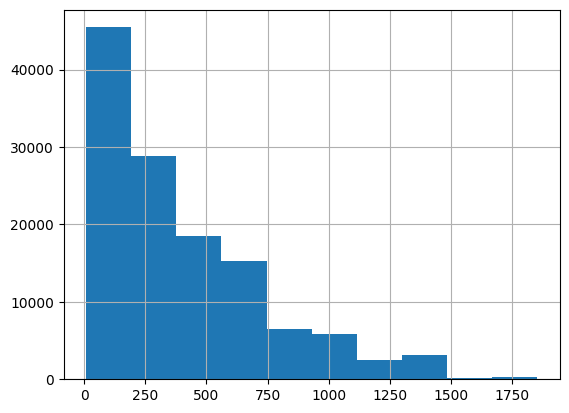

In [88]:
final_df['per_poverty_threshold']=final_df['answer']/final_df['poverty_threshold']*100
final_df['per_poverty_threshold'].hist()

In [89]:
all_merged_data = pd.merge(all_merged_data, final_df[['person_id', 'per_poverty_threshold']], on="person_id")

In [92]:
# This snippet assumes you run setup first

# This code saves your dataframe into a csv file in a "data" folder in Google Bucket

# Replace df with THE NAME OF YOUR DATAFRAME
my_dataframe = all_merged_data   

# Replace 'test.csv' with THE NAME of the file you're going to store in the bucket (don't delete the quotation marks)
destination_filename = 'All_SDoH_data.csv'

########################################################################
##
################# DON'T CHANGE FROM HERE ###############################
##
########################################################################

# save dataframe in a csv file in the same workspace as the notebook
my_dataframe.to_csv(destination_filename, index=False)

# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')

# copy csv file to the bucket
args = ["gsutil", "cp", f"./{destination_filename}", f"{my_bucket}/data/"]
output = subprocess.run(args, capture_output=True)


# Filter data

In [96]:
All_SDoH_data = all_merged_data 

ES = ('home_own','housing_quality','housing_instability', 'food_insecurity', 'per_poverty_threshold')
educ = 'education'
SCC = ('loneliness', 'discrimination', 'social_cohesion', 'stress', 'social_support', 'spirituality')
NBD = ('Walkability', 'crime_saftey', 'npd_scale', 'nsd_scale')
HCAU = ('health_literacy', 'health_discrim', 'health_coverage', 'health_care_use', 'delayed_care', 'afford_care', 'worried_pay', 'respect')

TypeError: list expected at most 1 argument, got 5

In [102]:
import pandas as pd

# Convert tuples to lists (important for pandas column indexing)
ES = list(ES)
SCC = list(SCC)
NBD = list(NBD)
HCAU = list(HCAU)

# Initial row count
print("Initial:", len(All_SDoH_data))

# Threshold checks (no filtering yet)
print("ES ≥3:", len(All_SDoH_data[All_SDoH_data[ES].notna().sum(axis=1) >= 3]))
print("Education present:", len(All_SDoH_data[All_SDoH_data[educ].notna()]))
print("SCC ≥4:", len(All_SDoH_data[All_SDoH_data[SCC].notna().sum(axis=1) >= 4]))
print("HCAU ≥5:", len(All_SDoH_data[All_SDoH_data[HCAU].notna().sum(axis=1) >= 5]))
print("NBD ≥3:", len(All_SDoH_data[All_SDoH_data[NBD].notna().sum(axis=1) >= 3]))

# Require education + poverty
df = All_SDoH_data.dropna(subset=[educ, 'per_poverty_threshold'])
print("After education + poverty filter:", len(df))

# Sequential domain filtering
df = df[df[ES].notna().sum(axis=1) >= 3]
df = df[df[SCC].notna().sum(axis=1) >= 4]
df = df[df[HCAU].notna().sum(axis=1) >= 5]
df = df[df[NBD].notna().sum(axis=1) >= 3]

print("Final:", len(df))

Initial: 156753
ES ≥3: 133092
Education present: 153286
SCC ≥4: 69507
HCAU ≥5: 87236
NBD ≥3: 67398
After education + poverty filter: 125295
Final: 54313


In [105]:
All_SDoH_data_domain_filtered_60.columns

Index(['person_id', 'date_of_birth', 'AIAN', 'Asian', 'Black', 'Mid',
       'Multiple', 'PI', 'White', 'His', 'race_unknown', 'SexGender',
       'age_today', 'where_born', 'military', 'healthcare', 'disabled',
       'sexual_orientation', 'LGBTQIA', 'min_date', 'max_date', 'ehr_length',
       'relative_health', 'record_depth', 'visit_frequency',
       'age_at_last_event', 'Education', 'employment', 'income', 'Own Home',
       'number_living', 'Health Literacy', 'Housing Quality',
       'Housing Instability', 'Food Insecurity', 'Walkability', 'Loneliness',
       'Crime', 'Physical Disorder', 'Social Disorder',
       'Everyday Discrimination', 'Medical Discrimination', 'Social Cohesion',
       'Stress', 'Social Support', 'Spiritual Experiences', 'Health Coverage',
       'Healthcare Utilization', 'Delayed Care', 'Can't afford care',
       'Worried Pay', 'Respect', 'Percent Poverty Threshold'],
      dtype='object')

In [106]:
# Rename columns
All_SDoH_data_domain_filtered_60 = df.rename(columns={
    "social_support": "Social Support",
    "loneliness": "Loneliness",
    "social_cohesion": "Social Cohesion",
    "discrimination": "Everyday Discrimination",
    "stress": "Stress",
    "spirituality": "Spiritual Experiences",
    "crime_saftey": "Crime",
    "npd_scale": "Physical Disorder",
    "nsd_scale": "Social Disorder",
    "Walkability": "Walkability",
    "home_own": "Own Home",
    "housing_quality": "Housing Quality",
    "housing_instability": "Housing Instability",
    "food_insecurity": "Food Insecurity",
    "per_poverty_threshold": "Percent Poverty Threshold",
    "health_literacy": "Health Literacy",
    "health_discrim": "Medical Discrimination",
    "health_coverage": "Health Coverage",
    "health_care_use": "Healthcare Utilization",
    "delayed_care": "Delayed Care",
    "afford_care": "Can't afford care",
    "worried_pay": "Worried Pay",
    "respect": "Respect",
    "education": "Education"
})

# Add age squared
All_SDoH_data_domain_filtered_60["age"] = All_SDoH_data_domain_filtered_60["age_at_last_event"]
All_SDoH_data_domain_filtered_60["age2"] = All_SDoH_data_domain_filtered_60["age"] ** 2



# Scale data

In [107]:
All_SDoH_data_domain_filtered_60.shape

(54313, 55)

In [108]:
All_SDoH_data_domain_filtered_60.columns

Index(['person_id', 'date_of_birth', 'AIAN', 'Asian', 'Black', 'Mid',
       'Multiple', 'PI', 'White', 'His', 'race_unknown', 'SexGender',
       'age_today', 'where_born', 'military', 'healthcare', 'disabled',
       'sexual_orientation', 'LGBTQIA', 'min_date', 'max_date', 'ehr_length',
       'relative_health', 'record_depth', 'visit_frequency',
       'age_at_last_event', 'Education', 'employment', 'income', 'Own Home',
       'number_living', 'Health Literacy', 'Housing Quality',
       'Housing Instability', 'Food Insecurity', 'Walkability', 'Loneliness',
       'Crime', 'Physical Disorder', 'Social Disorder',
       'Everyday Discrimination', 'Medical Discrimination', 'Social Cohesion',
       'Stress', 'Social Support', 'Spiritual Experiences', 'Health Coverage',
       'Healthcare Utilization', 'Delayed Care', 'Can't afford care',
       'Worried Pay', 'Respect', 'Percent Poverty Threshold', 'age', 'age2'],
      dtype='object')

In [109]:
column_indices = list(range(26, 53))
# Select the columns based on indices

columns_to_scale = All_SDoH_data_domain_filtered_60.iloc[:, column_indices]

columns_to_scale.columns

Index(['Education', 'employment', 'income', 'Own Home', 'number_living',
       'Health Literacy', 'Housing Quality', 'Housing Instability',
       'Food Insecurity', 'Walkability', 'Loneliness', 'Crime',
       'Physical Disorder', 'Social Disorder', 'Everyday Discrimination',
       'Medical Discrimination', 'Social Cohesion', 'Stress', 'Social Support',
       'Spiritual Experiences', 'Health Coverage', 'Healthcare Utilization',
       'Delayed Care', 'Can't afford care', 'Worried Pay', 'Respect',
       'Percent Poverty Threshold'],
      dtype='object')

In [110]:
from sklearn.preprocessing import StandardScaler

column_range = list(range(26, 53))
subset = all_merged_data.iloc[:, column_range]

# Identify binary columns: only 0/1 or 0/1/NaN
binary_cols = [col for col in subset.columns if subset[col].dropna().isin([0,1]).all()]

# Continuous columns are the rest
continuous_cols = [col for col in subset.columns if col not in binary_cols]

# Z-score only continuous columns
scaler = StandardScaler()
all_merged_data.loc[:, continuous_cols] = scaler.fit_transform(subset[continuous_cols])

# Binary columns remain unchanged



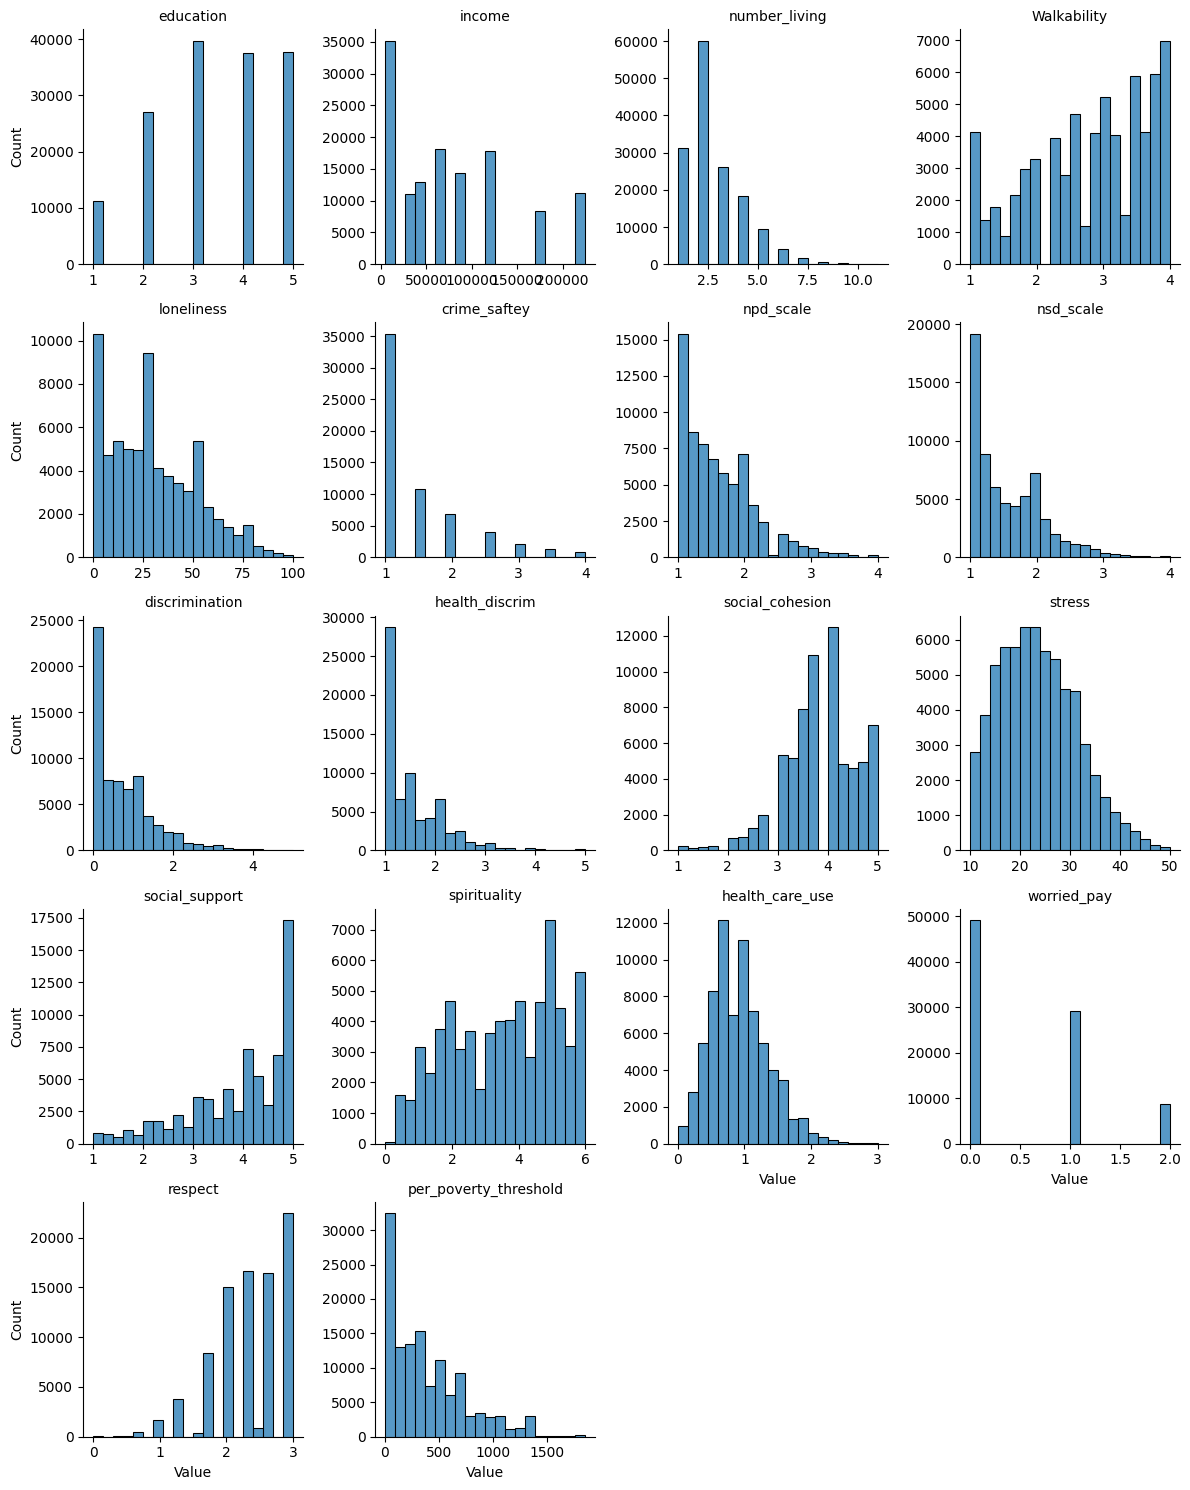

In [111]:
import seaborn as sns

cont_data = subset[continuous_cols]

# Melt to long format for faceting
long_df = cont_data.melt(var_name='Variable', value_name='Value')

# FacetGrid histogram
g = sns.FacetGrid(long_df, col='Variable', col_wrap=4, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='Value', bins=20, kde=False)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Value", "Count")
plt.tight_layout()
plt.show()

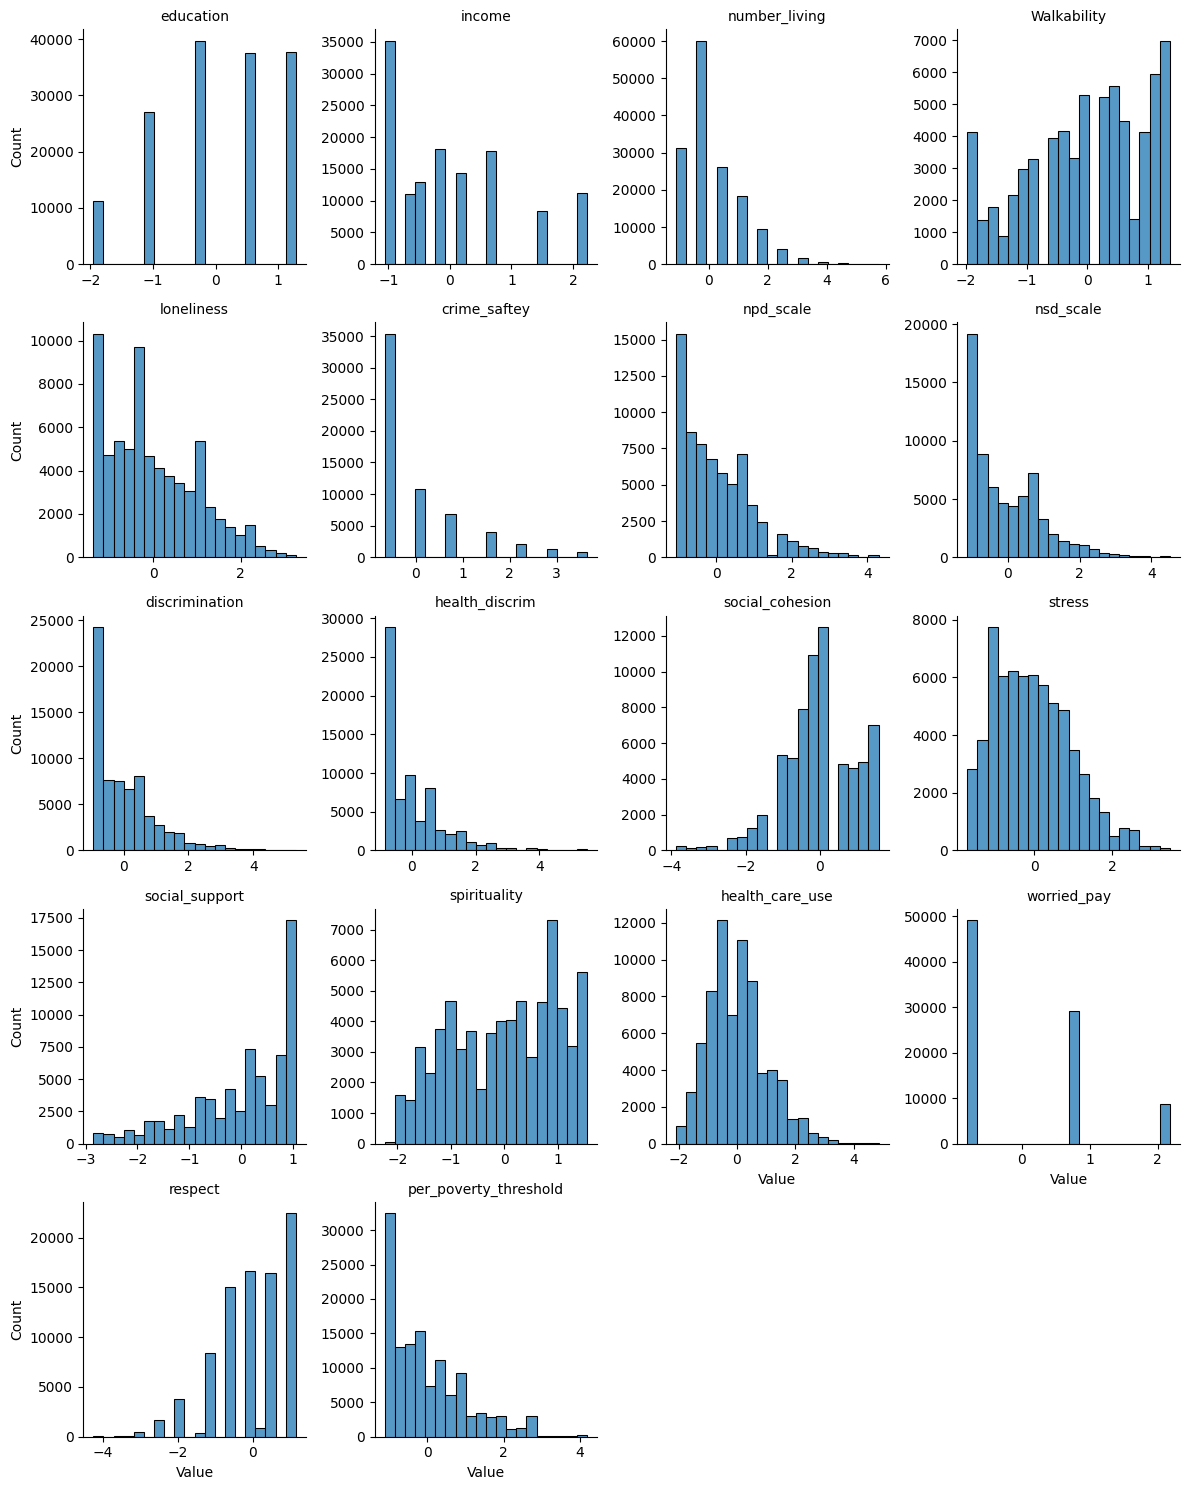

In [112]:
import seaborn as sns

cont_data = all_merged_data[continuous_cols]

# Melt to long format for faceting
long_df = cont_data.melt(var_name='Variable', value_name='Value')

# FacetGrid histogram
g = sns.FacetGrid(long_df, col='Variable', col_wrap=4, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='Value', bins=20, kde=False)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Value", "Count")
plt.tight_layout()
plt.show()